# Merged centroid and word-level VAD analysis

This notebook merges the centroid-plot notebook and the word-level VAD notebook into one reproducible pipeline.

It generates the missing Table 3.1 entries by computing correlations between embedding-side distances
\(\{d_\angle, d_G\}\) and the following affective ground-truth distances:

- label V
- label VAD
- comment-centroid V
- comment-centroid VAD
- comment VAD

The main outputs are saved under `OUT_DIR`:

- `table_3_1_distance_correlations.csv`
- `table_3_1_distance_correlations.tex`
- `table_3_1_all_candidates_long.csv`
- `word_vad_heatmap.png`
- centroid PCA and diagnostic scatter plots

The notebook deliberately keeps the method choices visible. Silent method-mixing is how tables become haunted little rectangles.


## 1. Imports

Run this in VSCode/Jupyter after installing the usual scientific Python stack:

```powershell
pip install numpy pandas scipy scikit-learn matplotlib plotly
```

`plotly` is only needed for the optional 3D diagnostic plot.


In [36]:
from pathlib import Path
import re
import math
import warnings
from collections import Counter

import numpy as np
import pandas as pd

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components, dijkstra
from scipy.stats import pearsonr, spearmanr, kendalltau

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:  # pragma: no cover
    display = print

try:
    import plotly.graph_objects as go
    import plotly.express as px
    HAS_PLOTLY = True
except Exception:
    HAS_PLOTLY = False

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.5,
})


## 2. Configuration

Change this cell first. The defaults assume your Windows project layout from the earlier notebooks.

The compact Table 3.1 now uses a single PCA setting for every row: `TABLE_PCA_DIM = 25`. Direct angular distances and KNN-geodesic distances are therefore computed after the same PCA reduction. For every KNN geodesic row, `k='auto'` means the code searches upward from `k=1` and uses the smallest `k` that makes the symmetric KNN graph connected. Humanity may continue pretending tables are simple.

In [37]:
SEED = 42
rng = np.random.default_rng(SEED)

PROJECT_DIR = Path(r"D:/pyprojects/m4r")
DATA_DIR = PROJECT_DIR / "data" / "goemotions"
MANIFOLD_DIR = DATA_DIR / "manifold_outputs"

METADATA_PATH = MANIFOLD_DIR / "metadata.csv"
EMBEDDINGS_PATH = MANIFOLD_DIR / "embeddings.npy"
VAD_CSV = DATA_DIR / "emotion_label_vad_starter.csv"

# BRM file name differs by case across earlier files. Windows shrugs; Linux complains.
BRM_CANDIDATES = [
    DATA_DIR / "BRM-emot-submit.csv",
    DATA_DIR / "brm-emot-submit.csv",
    PROJECT_DIR / "BRM-emot-submit.csv",
    Path("/mnt/data/BRM-emot-submit.csv"),
]

OUT_DIR = PROJECT_DIR / "new_plots" / "merged_ground_truth_table_pca25_connectedk"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Word-level VAD sampling. MAX_PER_LABEL=50 reproduces the earlier word-level notebook scale.
MAX_PER_LABEL = 50
MIN_MATCHED_WORDS = 1

# Compact paper-table geometry setting.
# Every row in Table 3.1 uses this PCA dimension for both d_angle and d_G.
TABLE_PCA_DIM = 25

# Comment-level geodesic is the expensive part. Keep the sample balanced and modest unless you enjoy waiting.
RUN_COMMENT_GEODESIC = True
COMMENT_GEODESIC_PCA_DIMS = TABLE_PCA_DIM
COMMENT_KNN_K = "auto"
COMMENT_KNN_K_MAX = 50

# Table candidates. We intentionally do not sweep PCA or k for the compact table.
# k='auto' calls connected_knn_graph(), which returns the smallest k that connects the symmetric KNN graph.
CENTROID_DIRECT_PCA_DIMS = [TABLE_PCA_DIM]
CENTROID_GEODESIC_PCA_DIMS = [TABLE_PCA_DIM]
CENTROID_K_VALUES = ["auto"]
CENTROID_KNN_K_MAX = 100

# Compact paper-table selector.
# Direct angular and geodesic rows both use PCA-25. Geodesic rows use the least connected k.
PAPER_LABEL_DIRECT_PCA_DIM = TABLE_PCA_DIM
PAPER_LEXICAL_DIRECT_PCA_DIM = TABLE_PCA_DIM
PAPER_COMMENT_DIRECT_PCA_DIM = TABLE_PCA_DIM
PAPER_GEODESIC_POLICY = "configured"  # fixed PCA-25, least connected k
PAPER_CONFIGURED_GEODESIC_PCA_DIM = TABLE_PCA_DIM
PAPER_CONFIGURED_GEODESIC_K = "auto"  # select the row produced by the least-connected-k search

# The earlier table used attention-weighted lexical VAD for comment-centroid VAD,
# but unweighted lexical VAD for the individual-comment row. Set these to "unweighted"
# for a simpler, fully consistent baseline.
PAPER_LEXICAL_CENTROID_VAD_MODE = "attention"   # "attention" or "unweighted"
PAPER_COMMENT_VAD_MODE = "attention"           # "attention" or "unweighted"

# Optional diagnostics from the centroid notebook.
FOCUS_LABELS = ["fear", "caring", "gratitude", "love"]
MAX_3D_PER_LABEL = None
PCA_3D_FIT_SCOPE = "global"  # "global" or "selected"
MAX_SCATTER_PAIRS = 60000

print("Metadata:", METADATA_PATH)
print("Embeddings:", EMBEDDINGS_PATH)
print("Label VAD:", VAD_CSV)
print("Output:", OUT_DIR)
print("Table PCA dimension:", TABLE_PCA_DIM)
print("KNN geodesic k policy: least k that keeps the symmetric KNN graph connected")


Metadata: D:\pyprojects\m4r\data\goemotions\manifold_outputs\metadata.csv
Embeddings: D:\pyprojects\m4r\data\goemotions\manifold_outputs\embeddings.npy
Label VAD: D:\pyprojects\m4r\data\goemotions\emotion_label_vad_starter.csv
Output: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk
Table PCA dimension: 25
KNN geodesic k policy: least k that keeps the symmetric KNN graph connected


## 3. Shared helpers


In [38]:
VAD_SPACES = {
    "VAD": ["valence", "arousal", "dominance"],
    "VA": ["valence", "arousal"],
    "V": ["valence"],
    "valence": ["valence"],
    "arousal": ["arousal"],
    "dominance": ["dominance"],
}


def first_existing(candidates):
    for p in candidates:
        p = Path(p)
        if p.exists():
            return p
    return Path(candidates[0])


def require_file(path: Path, description: str) -> Path:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing {description}: {path}")
    return path


def load_embeddings(path: Path) -> np.ndarray:
    path = require_file(path, "embeddings file")
    if path.suffix.lower() == ".npy":
        return np.load(path)
    return pd.read_csv(path, header=None).values


def load_label_vad(path: Path) -> pd.DataFrame:
    path = require_file(path, "label VAD CSV")
    vad = pd.read_csv(path)
    required = {"label_name", "valence", "arousal", "dominance"}
    missing = required - set(vad.columns)
    if missing:
        raise ValueError(f"VAD CSV missing required columns: {sorted(missing)}")
    vad = vad.copy()
    vad["label_name"] = vad["label_name"].astype(str)
    for col in ["valence", "arousal", "dominance"]:
        vad[col] = pd.to_numeric(vad[col], errors="coerce")
    if vad[["valence", "arousal", "dominance"]].isna().any().any():
        bad = vad[vad[["valence", "arousal", "dominance"]].isna().any(axis=1)]
        raise ValueError("Some VAD rows contain missing/non-numeric values:\n" + bad.to_string(index=False))
    return vad


def attach_label_vad(labels: pd.DataFrame, vad_df: pd.DataFrame) -> pd.DataFrame:
    out = labels.merge(
        vad_df[["label_name", "valence", "arousal", "dominance"]],
        on="label_name",
        how="left",
    )
    if out[["valence", "arousal", "dominance"]].isna().any().any():
        missing = sorted(out.loc[out["valence"].isna(), "label_name"].unique())
        raise ValueError(f"Missing VAD rows for labels: {missing}")
    return out


def make_embedding_centroids(X: np.ndarray, metadata: pd.DataFrame, vad_df: pd.DataFrame | None = None):
    if len(X) != len(metadata):
        raise ValueError(f"Embeddings and metadata length differ: {len(X)} vs {len(metadata)}")
    work = metadata[["label_idx", "label_name"]].copy() if "label_idx" in metadata.columns else metadata[["label_name"]].copy()
    work["_row"] = np.arange(len(work))
    rows = []
    centroids = []
    for label_name, group in work.groupby("label_name", sort=True):
        idx = group["_row"].to_numpy()
        centroids.append(X[idx].mean(axis=0))
        row = {"label_name": label_name, "n_comments": int(len(group))}
        if "label_idx" in group.columns:
            row["label_idx"] = int(group["label_idx"].iloc[0])
        rows.append(row)
    meta = pd.DataFrame(rows)
    if vad_df is not None:
        meta = attach_label_vad(meta, vad_df)
    return np.vstack(centroids), meta.reset_index(drop=True)


def normalize_rows(X_in: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return X_in / np.maximum(np.linalg.norm(X_in, axis=1, keepdims=True), eps)


def angular_pairwise(X_in: np.ndarray) -> np.ndarray:
    Xn = normalize_rows(np.asarray(X_in))
    sims = np.clip(Xn @ Xn.T, -1.0, 1.0)
    return np.arccos(sims)


def maybe_pca(X_in: np.ndarray, n_components: int | None, seed: int = SEED):
    if n_components is None or int(n_components) <= 0:
        return X_in, "raw", math.nan
    n = min(int(n_components), X_in.shape[0] - 1, X_in.shape[1])
    if n < 1:
        return X_in, "raw", math.nan
    pca = PCA(n_components=n, random_state=seed)
    Z = pca.fit_transform(X_in)
    return Z, f"pca_{n}", float(pca.explained_variance_ratio_.sum())


def build_symmetric_knn_graph(X_in: np.ndarray, k: int, metric: str = "angular") -> csr_matrix:
    n = X_in.shape[0]
    if k >= n:
        raise ValueError(f"k={k} must be smaller than n={n}")
    if k < 1:
        raise ValueError("k must be at least 1")

    if metric == "angular":
        Xn = normalize_rows(X_in)
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric="cosine")
        nbrs.fit(Xn)
        _, indices = nbrs.kneighbors(Xn)
        indices = indices[:, 1:]
        rows = np.repeat(np.arange(n), k)
        cols = indices.ravel()
        sims = np.sum(Xn[rows] * Xn[cols], axis=1)
        vals = np.arccos(np.clip(sims, -1.0, 1.0))
    else:
        nbrs = NearestNeighbors(n_neighbors=k + 1, metric=metric)
        nbrs.fit(X_in)
        distances, indices = nbrs.kneighbors(X_in)
        rows = np.repeat(np.arange(n), k)
        cols = indices[:, 1:].ravel()
        vals = distances[:, 1:].ravel()

    G = csr_matrix((vals, (rows, cols)), shape=(n, n))
    return G.maximum(G.T)


def connected_knn_graph(X_in: np.ndarray, metric: str = "angular", k_max: int = 100):
    upper = min(k_max, X_in.shape[0] - 1)
    for k in range(1, upper + 1):
        G = build_symmetric_knn_graph(X_in, k=k, metric=metric)
        n_components, _ = connected_components(G, directed=False)
        if n_components == 1:
            return k, G, int(n_components)
    warnings.warn(f"KNN graph did not become connected up to k={upper}; using k={upper} anyway.")
    G = build_symmetric_knn_graph(X_in, k=upper, metric=metric)
    n_components, _ = connected_components(G, directed=False)
    return upper, G, int(n_components)


def knn_geodesic_distance(X_in: np.ndarray, k="auto", metric: str = "angular", k_max: int = 100):
    if k == "auto":
        actual_k, G, n_components = connected_knn_graph(X_in, metric=metric, k_max=k_max)
    else:
        actual_k = int(k)
        G = build_symmetric_knn_graph(X_in, k=actual_k, metric=metric)
        n_components, _ = connected_components(G, directed=False)
    D = dijkstra(csgraph=G, directed=False, return_predecessors=False)
    return D, int(actual_k), int(n_components)


def upper_values(D: np.ndarray) -> np.ndarray:
    iu = np.triu_indices(D.shape[0], k=1)
    return D[iu]


def pair_index(n: int):
    return np.triu_indices(n, k=1)


def distance_from_vad_values(V: np.ndarray, space: str = "VAD") -> np.ndarray:
    if space not in VAD_SPACES:
        raise ValueError(f"Unknown VAD space {space!r}. Use one of {sorted(VAD_SPACES)}")
    col_idx = [{"valence": 0, "arousal": 1, "dominance": 2}[c] for c in VAD_SPACES[space]]
    return pairwise_distances(V[:, col_idx], metric="euclidean")


def corr_stats(truth: np.ndarray, rep: np.ndarray) -> dict[str, float]:
    mask = np.isfinite(truth) & np.isfinite(rep)
    truth = truth[mask]
    rep = rep[mask]
    out = {"n_pairs": int(len(truth))}
    if len(truth) < 3 or np.std(truth) == 0 or np.std(rep) == 0:
        return {**out, "pearson_r": np.nan, "pearson_p": np.nan, "spearman_rho": np.nan, "spearman_p": np.nan, "kendall_tau": np.nan, "kendall_p": np.nan}
    pr = pearsonr(truth, rep)
    sr = spearmanr(truth, rep)
    kt = kendalltau(truth, rep)
    return {
        **out,
        "pearson_r": float(pr.statistic),
        "pearson_p": float(pr.pvalue),
        "spearman_rho": float(sr.statistic),
        "spearman_p": float(sr.pvalue),
        "kendall_tau": float(kt.statistic),
        "kendall_p": float(kt.pvalue),
    }


def add_candidate(rows, ground_truth_name, level, ground_truth_D, embedding_D, distance_kind, representation, pca_dim, k=None, components=None, explained_variance=math.nan):
    stats = corr_stats(upper_values(ground_truth_D), upper_values(embedding_D))
    rows.append({
        "ground_truth_distance": ground_truth_name,
        "level": level,
        "embedding_distance": distance_kind,
        "representation": representation,
        "pca_dim": pca_dim,
        "knn_k": "" if k is None else k,
        "graph_components": "" if components is None else components,
        "explained_variance": explained_variance,
        **stats,
    })


def clean_axes(ax):
    ax.grid(True, linewidth=0.5, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def save_matplotlib(fig, stem: str) -> None:
    png_path = OUT_DIR / f"{stem}.png"
    svg_path = OUT_DIR / f"{stem}.svg"
    fig.savefig(png_path, bbox_inches="tight")
    fig.savefig(svg_path, bbox_inches="tight")
    print(f"Saved: {png_path}")
    print(f"Saved: {svg_path}")


## 4. Load embeddings, metadata, label VAD, and BRM lexicon


In [39]:
BRM_PATH = first_existing(BRM_CANDIDATES)

metadata = pd.read_csv(require_file(METADATA_PATH, "metadata.csv"))
X = load_embeddings(EMBEDDINGS_PATH)
label_vad_df = load_label_vad(VAD_CSV)

if len(metadata) != len(X):
    raise ValueError(f"metadata rows ({len(metadata)}) != embedding rows ({len(X)}). Something is misaligned.")
if "label_name" not in metadata.columns:
    raise ValueError("metadata.csv must contain a label_name column")
if "text" not in metadata.columns:
    raise ValueError("metadata.csv must contain a text column for word-level VAD")

metadata = metadata.reset_index(drop=True)
metadata["_embedding_row"] = np.arange(len(metadata))

label_centroid_X, label_centroid_meta = make_embedding_centroids(X, metadata, label_vad_df)
label_vad = label_centroid_meta[["valence", "arousal", "dominance"]].to_numpy(dtype=float)

print("Embeddings:", X.shape)
print("Metadata:", metadata.shape)
print("Label centroids:", label_centroid_X.shape)
print("BRM path:", BRM_PATH)
display(label_centroid_meta.head())
display(metadata["label_name"].value_counts().sort_index().to_frame("available"))


Embeddings: (4997, 3072)
Metadata: (4997, 6)
Label centroids: (28, 3072)
BRM path: D:\pyprojects\m4r\data\goemotions\BRM-emot-submit.csv


,label_name,n_comments,label_idx,valence,arousal,dominance
0,admiration,201,0,7.74,6.11,7.53
1,amusement,201,1,7.00,6.00,6.00
2,anger,201,2,2.85,7.17,5.55
3,annoyance,201,3,2.74,6.49,5.09
4,approval,201,4,7.33,5.83,6.89


,available
label_name,
admiration,201
amusement,201
anger,201
annoyance,201
approval,201
caring,201
confusion,201
curiosity,201
desire,201


## 5. Parse BRM word-level VAD

This parser tolerates column names such as `Word`, `V`, `A`, `D`, `V.Mean.Sum`, and similar variants.


In [40]:
def _norm_col(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(name).lower())


def infer_brm_columns(df: pd.DataFrame) -> dict[str, str]:
    norm_to_orig = {_norm_col(c): c for c in df.columns}
    norms = list(norm_to_orig)

    def first_exact(candidates):
        for cand in candidates:
            key = _norm_col(cand)
            if key in norm_to_orig:
                return norm_to_orig[key]
        return None

    word_col = first_exact(["word", "words", "term", "item"])
    if word_col is None:
        word_col = df.columns[0]

    def infer_axis(axis_letter: str, axis_name: str):
        exact = first_exact([
            axis_name,
            f"{axis_name}_mean",
            f"{axis_name}.mean",
            axis_letter,
            f"{axis_letter}.Mean.Sum",
            f"{axis_letter}_Mean_Sum",
            f"{axis_letter}MeanSum",
            f"{axis_letter}.Mean",
            f"{axis_letter}_Mean",
        ])
        if exact is not None:
            return exact
        for norm_name in norms:
            has_axis = norm_name.startswith(axis_letter.lower()) or axis_name.lower() in norm_name
            has_mean = "mean" in norm_name or "avg" in norm_name
            if has_axis and has_mean:
                return norm_to_orig[norm_name]
        for norm_name in norms:
            if norm_name.startswith(axis_letter.lower()):
                return norm_to_orig[norm_name]
        raise ValueError(f"Could not infer {axis_name} column. Columns are: {list(df.columns)}")

    return {
        "word": word_col,
        "valence": infer_axis("V", "valence"),
        "arousal": infer_axis("A", "arousal"),
        "dominance": infer_axis("D", "dominance"),
    }


brm_raw = pd.read_csv(require_file(BRM_PATH, "BRM word-level VAD lexicon"))
cols = infer_brm_columns(brm_raw)
print("Inferred BRM columns:", cols)

brm = brm_raw[[cols["word"], cols["valence"], cols["arousal"], cols["dominance"]]].copy()
brm.columns = ["word", "valence", "arousal", "dominance"]
brm["word"] = brm["word"].astype(str).str.lower().str.strip()
for c in ["valence", "arousal", "dominance"]:
    brm[c] = pd.to_numeric(brm[c], errors="coerce")

brm = brm.dropna(subset=["word", "valence", "arousal", "dominance"])
brm = brm[brm["word"].str.len() > 0].drop_duplicates("word", keep="first").reset_index(drop=True)

vad_lookup = {
    row.word: np.array([row.valence, row.arousal, row.dominance], dtype=np.float32)
    for row in brm.itertuples(index=False)
}

print("BRM rows usable:", len(brm))
display(brm.head())
display(brm[["valence", "arousal", "dominance"]].describe())


Inferred BRM columns: {'word': 'Word', 'valence': 'V', 'arousal': 'A', 'dominance': 'D'}
BRM rows usable: 13905


,word,valence,arousal,dominance
0,aardvark,6.26,2.41,4.27
1,abalone,5.30,2.65,4.95
2,abandon,2.84,3.73,3.32
3,abandonment,2.63,4.95,2.64
4,abbey,5.85,2.20,5.00


,valence,arousal,dominance
count,13905.000000,13905.000000,13905.000000
mean,5.064042,4.210642,5.185007
std,1.274727,0.896671,0.938333
min,1.260000,1.600000,1.680000
25%,4.250000,3.560000,4.580000
50%,5.200000,4.110000,5.260000
75%,5.950000,4.760000,5.840000
max,8.530000,7.790000,7.900000


## 6. Build comment-level word-derived VAD

Two lexical VAD variants are produced:

1. **Unweighted**: simple average over matched BRM words.
2. **Attention-weighted**: a lightweight IDF/intensity weighting with crude negation handling.

This is still a lexicon baseline, not a mind-reading device. Humanity keeps asking spreadsheets to understand irony; the spreadsheets are doing their best.


In [41]:
TOKEN_RE = re.compile(r"[a-z]+(?:'[a-z]+)?")


def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(str(text).lower())


def comment_to_word_vad(text: str, lookup: dict[str, np.ndarray]):
    tokens = tokenize(text)
    vals = []
    matched = []
    for tok in tokens:
        if tok in lookup:
            vals.append(lookup[tok])
            matched.append(tok)
    if not vals:
        return {
            "word_vad": np.array([np.nan, np.nan, np.nan], dtype=np.float32),
            "n_tokens": len(tokens),
            "n_vad_words": 0,
            "coverage": 0.0 if tokens else np.nan,
            "matched_words": "",
        }
    arr = np.vstack(vals)
    return {
        "word_vad": arr.mean(axis=0),
        "n_tokens": len(tokens),
        "n_vad_words": len(vals),
        "coverage": len(vals) / max(1, len(tokens)),
        "matched_words": " ".join(matched[:25]),
    }


records = []
word_vads = []
for row in metadata.itertuples(index=False):
    res = comment_to_word_vad(row.text, vad_lookup)
    word_vads.append(res.pop("word_vad"))
    records.append(res)

vad_info = pd.DataFrame(records)
word_vad = np.vstack(word_vads)

comment_vad = pd.concat(
    [
        metadata[["_embedding_row", "text", "label_name"]].reset_index(drop=True),
        vad_info,
        pd.DataFrame(word_vad, columns=["word_valence", "word_arousal", "word_dominance"]),
    ],
    axis=1,
)

comment_vad["has_word_vad"] = (
    comment_vad["n_vad_words"].ge(MIN_MATCHED_WORDS)
    & comment_vad[["word_valence", "word_arousal", "word_dominance"]].notna().all(axis=1)
)

comment_vad_path = OUT_DIR / "comment_word_vad_table.csv"
comment_vad.to_csv(comment_vad_path, index=False)

print("Saved:", comment_vad_path)
print("Comments with word VAD:", int(comment_vad["has_word_vad"].sum()), "/", len(comment_vad))
print("Mean coverage among usable comments:", comment_vad.loc[comment_vad["has_word_vad"], "coverage"].mean())
display(comment_vad.head())
display(
    comment_vad.groupby("label_name")
    .agg(
        n=("label_name", "size"),
        usable=("has_word_vad", "sum"),
        mean_matched_words=("n_vad_words", "mean"),
        mean_coverage=("coverage", "mean"),
    )
    .sort_index()
)


Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\comment_word_vad_table.csv
Comments with word VAD: 4848 / 4997
Mean coverage among usable comments: 0.339458241775883


,_embedding_row,text,label_name,n_tokens,n_vad_words,coverage,matched_words,word_valence,word_arousal,word_dominance,has_word_vad
0,0,Your idea of what a nice entre or nice wine co...,admiration,16,7,0.437500,idea nice nice wine cost restaurant interesting,6.377143,4.307143,5.862857,True
1,1,I am so relieved,relief,4,0,0.000000,,NaN,NaN,NaN,False
2,2,A reason to play the game every 3 month?,curiosity,8,4,0.500000,reason play game month,6.597500,3.957500,5.822500,True
3,3,Lakers truly have the worst fans,annoyance,6,1,0.166667,have,5.860000,3.520000,5.720000,True
4,4,Great way to clarify! That's the whole point o...,approval,15,7,0.466667,great way clarify whole point stuff like,6.288571,3.592857,5.877143,True


,n,usable,mean_matched_words,mean_coverage
label_name,,,,
admiration,201,198,3.875622,0.395146
amusement,201,189,3.318408,0.283721
anger,201,198,4.129353,0.371085
annoyance,201,199,4.502488,0.332588
approval,201,192,4.114428,0.307865
caring,201,198,4.840796,0.382216
confusion,201,196,3.985075,0.280191
curiosity,201,186,3.736318,0.290721
desire,201,200,4.721393,0.349340


## 7. Balanced comment sample and attention-weighted lexical VAD

The individual-comment row in Table 3.1 uses this balanced sample so the pairwise calculation is not dominated by labels with more examples.


In [42]:
usable = comment_vad[comment_vad["has_word_vad"]].copy()
if usable.empty:
    raise ValueError("No usable comments after BRM matching. Check BRM_PATH or lower MIN_MATCHED_WORDS.")

sampled = (
    usable.groupby("label_name", group_keys=False)
    .apply(lambda g: g.sample(n=min(len(g), MAX_PER_LABEL), random_state=SEED))
    .sample(frac=1.0, random_state=SEED)
    .reset_index(drop=True)
)

idx = sampled["_embedding_row"].to_numpy(dtype=int)
X_sample = X[idx]
V_sample_unweighted = sampled[["word_valence", "word_arousal", "word_dominance"]].to_numpy(dtype=np.float32)

sampled_path = OUT_DIR / "sampled_comments_with_word_vad.csv"
sampled.to_csv(sampled_path, index=False)

print("Sampled comments:", len(sampled))
print("Pair count:", len(sampled) * (len(sampled) - 1) // 2)
print("Saved:", sampled_path)
display(sampled["label_name"].value_counts().sort_index().to_frame("sampled"))


Sampled comments: 1372
Pair count: 940506
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\sampled_comments_with_word_vad.csv


C:\Users\86183\AppData\Local\Temp\ipykernel_17636\614711475.py:7: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



,sampled
label_name,
admiration,50
amusement,50
anger,50
annoyance,50
approval,50
caring,50
confusion,50
curiosity,50
desire,50


In [43]:
NEGATORS = {
    "not", "no", "never", "none", "nothing", "nobody", "neither", "nor", "without",
    "don't", "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't",
    "can't", "couldn't", "won't", "wouldn't", "shouldn't",
}
STOPWORDS = set(ENGLISH_STOP_WORDS) - NEGATORS
NEUTRAL_VAD = np.array([5.0, 5.0, 5.0], dtype=np.float32)


def build_idf_lookup(texts, lookup):
    doc_freq = Counter()
    n_docs = 0
    for text in texts:
        toks = {t for t in set(tokenize(text)) if t in lookup}
        if toks:
            n_docs += 1
            doc_freq.update(toks)
    return {word: np.log((1 + n_docs) / (1 + df)) + 1.0 for word, df in doc_freq.items()}


def attention_weighted_word_vad(text, lookup, idf_lookup, beta=2.0, intensity_gamma=2.0, negation_window=3):
    tokens = tokenize(text)
    vals = []
    logits = []
    matched_words = []
    neg_scope = 0

    for tok in tokens:
        if tok in NEGATORS:
            neg_scope = negation_window
            continue
        if tok not in lookup:
            if neg_scope > 0:
                neg_scope -= 1
            continue
        if tok in STOPWORDS:
            if neg_scope > 0:
                neg_scope -= 1
            continue

        vad = lookup[tok].astype(np.float32).copy()
        if neg_scope > 0:
            vad[0] = 10.0 - vad[0]

        centered = vad - NEUTRAL_VAD
        intensity = np.linalg.norm(centered) / np.sqrt(3 * 4**2)
        idf = idf_lookup.get(tok, 1.0)
        logit = np.log(idf + 1e-8) + intensity_gamma * intensity

        vals.append(vad)
        logits.append(logit)
        matched_words.append(tok)

        if neg_scope > 0:
            neg_scope -= 1

    if not vals:
        return {
            "vad": np.array([np.nan, np.nan, np.nan], dtype=np.float32),
            "n_attention_words": 0,
            "attention_words": "",
        }

    vals = np.vstack(vals)
    logits = np.array(logits, dtype=np.float32)
    weights = np.exp(beta * (logits - logits.max()))
    weights = weights / weights.sum()
    weighted_vad = weights @ vals

    top_idx = np.argsort(weights)[::-1][:8]
    top_words = [f"{matched_words[i]}:{weights[i]:.2f}" for i in top_idx]

    return {
        "vad": weighted_vad.astype(np.float32),
        "n_attention_words": len(vals),
        "attention_words": " ".join(top_words),
    }


idf_lookup = build_idf_lookup(metadata["text"].tolist(), vad_lookup)

attention_rows = []
attention_vads = []
for text in sampled["text"]:
    res = attention_weighted_word_vad(text, vad_lookup, idf_lookup)
    attention_vads.append(res.pop("vad"))
    attention_rows.append(res)

attention_info = pd.DataFrame(attention_rows)
V_sample_attention = np.vstack(attention_vads)

missing = ~np.isfinite(V_sample_attention).all(axis=1)
print("Comments needing fallback to unweighted VAD:", int(missing.sum()), "/", len(missing))
V_sample_attention[missing] = V_sample_unweighted[missing]

sampled_attention = sampled.copy()
sampled_attention[["attn_valence", "attn_arousal", "attn_dominance"]] = V_sample_attention
sampled_attention = pd.concat([sampled_attention, attention_info], axis=1)

attention_path = OUT_DIR / "sampled_comments_with_attention_weighted_vad.csv"
sampled_attention.to_csv(attention_path, index=False)
print("Saved:", attention_path)
display(sampled_attention[["text", "label_name", "attention_words", "attn_valence", "attn_arousal", "attn_dominance"]].head(12))


Comments needing fallback to unweighted VAD: 16 / 1372
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\sampled_comments_with_attention_weighted_vad.csv


,text,label_name,attention_words,attn_valence,attn_arousal,attn_dominance
0,I had a friend from Palestine who became athei...,desire,wish:0.31 friend:0.30 atheist:0.21 know:0.18,6.442910,3.921841,6.079362
1,I'll take the Akot 3 but man that shot is ugly,disgust,shot:0.48 ugly:0.46 man:0.07,2.835036,5.402291,3.742178
2,Don’t worry! I was never convicted of anything!,caring,worry:1.00,2.100000,6.330000,3.170000
3,[NAME] already had that in their comment and I...,annoyance,level:0.23 community:0.20 college:0.16 attenti...,6.087258,3.722705,5.902830
4,"Confirmed, word added to Oxford dictionary in ...",approval,dictionary:0.28 spread:0.18 circulation:0.14 w...,5.737701,3.648597,5.906579
5,We cant even get sexually assaulted without th...,disgust,gross:1.00,3.200000,5.000000,4.620000
6,"""Sponge Blurb Pubs Quaw Haha GURR ha AAa!"" fin...",amusement,sponge:0.39 finale:0.32 real:0.29,5.868419,4.197954,5.855309
7,I'm working on it. But there is always the fea...,fear,fear:1.00,2.930000,6.140000,3.320000
8,i wish i wasn’t a failure of a person.,desire,failure:0.60 wish:0.23 person:0.17,3.978101,4.405218,5.541812
9,The women-are-wonderful effect.,admiration,wonderful:0.74 effect:0.26,6.920817,4.444503,6.854487


## 8. Build lexical centroids

The lexical centroid rows average both embeddings and word-derived VAD within each emotion label, using the balanced sampled comments. This reproduces the earlier word-level notebook's centroid calculation.


In [44]:
def make_lexical_centroids(sample_df: pd.DataFrame, X_sample_in: np.ndarray, V_sample_in: np.ndarray):
    rows = []
    X_centroids = []
    V_centroids = []
    sample_df = sample_df.reset_index(drop=True)
    for label_name, group in sample_df.groupby("label_name", sort=True):
        idx = group.index.to_numpy()
        X_centroids.append(X_sample_in[idx].mean(axis=0))
        V_centroids.append(V_sample_in[idx].mean(axis=0))
        rows.append({
            "label_name": label_name,
            "n_comments": int(len(group)),
            "word_vad_valence": float(V_sample_in[idx, 0].mean()),
            "word_vad_arousal": float(V_sample_in[idx, 1].mean()),
            "word_vad_dominance": float(V_sample_in[idx, 2].mean()),
        })
    return np.vstack(X_centroids), np.vstack(V_centroids), pd.DataFrame(rows).reset_index(drop=True)


lexical_mode_to_V = {
    "unweighted": V_sample_unweighted,
    "attention": V_sample_attention,
}
if PAPER_LEXICAL_CENTROID_VAD_MODE not in lexical_mode_to_V:
    raise ValueError("PAPER_LEXICAL_CENTROID_VAD_MODE must be 'unweighted' or 'attention'")
if PAPER_COMMENT_VAD_MODE not in lexical_mode_to_V:
    raise ValueError("PAPER_COMMENT_VAD_MODE must be 'unweighted' or 'attention'")

X_lex_centroid, V_lex_centroid, lexical_centroid_df = make_lexical_centroids(
    sampled,
    X_sample,
    lexical_mode_to_V[PAPER_LEXICAL_CENTROID_VAD_MODE],
)

lexical_centroid_path = OUT_DIR / "lexical_centroids_for_table.csv"
lexical_centroid_df.to_csv(lexical_centroid_path, index=False)

print("Lexical centroids:", X_lex_centroid.shape, V_lex_centroid.shape)
print("Saved:", lexical_centroid_path)
display(lexical_centroid_df)


Lexical centroids: (28, 3072) (28, 3)
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\lexical_centroids_for_table.csv


,label_name,n_comments,word_vad_valence,word_vad_arousal,word_vad_dominance
0,admiration,50,6.736225,4.335677,6.100693
1,amusement,50,5.948177,4.711563,5.696460
2,anger,50,4.590676,4.892207,5.074550
3,annoyance,50,5.202298,4.423126,5.280131
4,approval,50,5.686768,4.217762,5.812004
5,caring,50,6.032411,4.243617,5.715474
6,confusion,50,4.947486,4.106511,5.378094
7,curiosity,50,5.658720,4.369248,5.551792
8,desire,50,6.171307,4.126559,5.859436
9,disappointment,50,5.060324,4.397242,5.342976


## 9. Compute embedding distances and ground-truth distances

This is the section that fills the table gap. It creates a complete long candidate table and then a compact paper table with one row per requested ground-truth distance.


In [45]:
# Label ground-truth distances.
D_label_V = distance_from_vad_values(label_vad, "V")
D_label_VAD = distance_from_vad_values(label_vad, "VAD")

# Lexical centroid ground-truth distances.
D_lex_V = distance_from_vad_values(V_lex_centroid, "V")
D_lex_VAD = distance_from_vad_values(V_lex_centroid, "VAD")

# Individual-comment ground-truth distance.
V_comment_for_table = lexical_mode_to_V[PAPER_COMMENT_VAD_MODE]
D_comment_VAD = distance_from_vad_values(V_comment_for_table, "VAD")

print("Ground-truth matrices:")
for name, D in {
    "Label V": D_label_V,
    "Label VAD": D_label_VAD,
    "Comment-centroid V": D_lex_V,
    "Comment-centroid VAD": D_lex_VAD,
    "Comment VAD": D_comment_VAD,
}.items():
    print(f"  {name}: {D.shape}, pairs={len(upper_values(D))}")


Ground-truth matrices:
  Label V: (28, 28), pairs=378
  Label VAD: (28, 28), pairs=378
  Comment-centroid V: (28, 28), pairs=378
  Comment-centroid VAD: (28, 28), pairs=378
  Comment VAD: (1372, 1372), pairs=940506


In [46]:
def compute_centroid_candidates(X_centroid: np.ndarray, truth_matrices: dict[str, np.ndarray], level: str, direct_pca_dims, geodesic_pca_dims, k_values):
    rows = []
    for pca_dim in direct_pca_dims:
        Z, rep_name, ev = maybe_pca(X_centroid, pca_dim, seed=SEED)
        D_angle = angular_pairwise(Z)
        for truth_name, truth_D in truth_matrices.items():
            add_candidate(
                rows,
                ground_truth_name=truth_name,
                level=level,
                ground_truth_D=truth_D,
                embedding_D=D_angle,
                distance_kind="d_angle",
                representation=rep_name,
                pca_dim=pca_dim,
                explained_variance=ev,
            )

    for pca_dim in geodesic_pca_dims:
        Z, rep_name, ev = maybe_pca(X_centroid, pca_dim, seed=SEED)
        for kval in k_values:
            if isinstance(kval, int) and kval >= Z.shape[0]:
                continue
            try:
                D_geo, actual_k, components = knn_geodesic_distance(Z, k=kval, metric="angular", k_max=CENTROID_KNN_K_MAX)
            except Exception as exc:
                warnings.warn(f"Skipping geodesic for {level}, {rep_name}, k={kval}: {exc}")
                continue
            for truth_name, truth_D in truth_matrices.items():
                add_candidate(
                    rows,
                    ground_truth_name=truth_name,
                    level=level,
                    ground_truth_D=truth_D,
                    embedding_D=D_geo,
                    distance_kind="d_G",
                    representation=rep_name,
                    pca_dim=pca_dim,
                    k=actual_k,
                    components=components,
                    explained_variance=ev,
                )
    return rows


candidate_rows = []

candidate_rows.extend(compute_centroid_candidates(
    label_centroid_X,
    {"Label V": D_label_V, "Label VAD": D_label_VAD},
    level="label centroids",
    direct_pca_dims=CENTROID_DIRECT_PCA_DIMS,
    geodesic_pca_dims=CENTROID_GEODESIC_PCA_DIMS,
    k_values=CENTROID_K_VALUES,
))

candidate_rows.extend(compute_centroid_candidates(
    X_lex_centroid,
    {"Comment-centroid V": D_lex_V, "Comment-centroid VAD": D_lex_VAD},
    level="lexical centroids",
    direct_pca_dims=CENTROID_DIRECT_PCA_DIMS,
    geodesic_pca_dims=CENTROID_GEODESIC_PCA_DIMS,
    k_values=CENTROID_K_VALUES,
))

# Individual-comment row. Direct angular is computed on raw comments by default.
Z_comment_direct, rep_comment_direct, ev_comment_direct = maybe_pca(X_sample, PAPER_COMMENT_DIRECT_PCA_DIM, seed=SEED)
D_comment_angle = angular_pairwise(Z_comment_direct)
add_candidate(
    candidate_rows,
    ground_truth_name="Comment VAD",
    level="individual comments",
    ground_truth_D=D_comment_VAD,
    embedding_D=D_comment_angle,
    distance_kind="d_angle",
    representation=rep_comment_direct,
    pca_dim=PAPER_COMMENT_DIRECT_PCA_DIM,
    explained_variance=ev_comment_direct,
)

if RUN_COMMENT_GEODESIC:
    Z_comment_geo, rep_comment_geo, ev_comment_geo = maybe_pca(X_sample, COMMENT_GEODESIC_PCA_DIMS, seed=SEED)
    D_comment_geo, comment_k, comment_components = knn_geodesic_distance(
        Z_comment_geo,
        k=COMMENT_KNN_K,
        metric="angular",
        k_max=COMMENT_KNN_K_MAX,
    )
    add_candidate(
        candidate_rows,
        ground_truth_name="Comment VAD",
        level="individual comments",
        ground_truth_D=D_comment_VAD,
        embedding_D=D_comment_geo,
        distance_kind="d_G",
        representation=rep_comment_geo,
        pca_dim=COMMENT_GEODESIC_PCA_DIMS,
        k=comment_k,
        components=comment_components,
        explained_variance=ev_comment_geo,
    )
    print(f"Comment geodesic: representation={rep_comment_geo}, k={comment_k}, components={comment_components}, EV={ev_comment_geo}")

all_candidates = pd.DataFrame(candidate_rows)
all_candidates = all_candidates.sort_values(
    ["ground_truth_distance", "level", "embedding_distance", "spearman_rho"],
    ascending=[True, True, True, False],
).reset_index(drop=True)

long_path = OUT_DIR / "table_3_1_all_candidates_long.csv"
all_candidates.to_csv(long_path, index=False)
print("Saved:", long_path)
display(all_candidates.head(30))


Comment geodesic: representation=pca_25, k=2, components=1, EV=0.2599406838417053
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\table_3_1_all_candidates_long.csv


,ground_truth_distance,level,embedding_distance,representation,pca_dim,knn_k,graph_components,explained_variance,n_pairs,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p
0,Comment VAD,individual comments,d_G,pca_25,25,2,1,0.259941,940506,0.032457,1.402580e-217,0.024320,4.990448e-123,0.016253,1.371455e-123
1,Comment VAD,individual comments,d_angle,pca_25,25,,,0.259941,940506,0.095614,0.000000e+00,0.094791,0.000000e+00,0.063273,0.000000e+00
2,Comment-centroid V,lexical centroids,d_G,pca_25,25,3,1,0.982408,378,0.707925,9.549289e-59,0.700691,4.318956e-57,0.500091,9.442716e-48
3,Comment-centroid V,lexical centroids,d_angle,pca_25,25,,,0.982408,378,0.580510,1.965577e-35,0.620358,1.408681e-41,0.431154,6.109765e-36
4,Comment-centroid VAD,lexical centroids,d_G,pca_25,25,3,1,0.982408,378,0.688661,1.908798e-54,0.686748,4.892212e-54,0.486169,3.160791e-45
5,Comment-centroid VAD,lexical centroids,d_angle,pca_25,25,,,0.982408,378,0.565071,2.848138e-33,0.600349,2.197918e-38,0.417344,8.793171e-34
6,Label V,label centroids,d_G,pca_25,25,2,1,0.992096,378,0.691429,4.826175e-55,0.666773,5.977933e-50,0.459748,1.464362e-40
7,Label V,label centroids,d_angle,pca_25,25,,,0.992096,378,0.591358,5.068387e-37,0.623003,5.120015e-42,0.430277,9.666456e-36
8,Label VAD,label centroids,d_G,pca_25,25,2,1,0.992096,378,0.694175,1.214858e-55,0.674093,2.071191e-51,0.475011,2.982520e-43
9,Label VAD,label centroids,d_angle,pca_25,25,,,0.992096,378,0.604641,4.743202e-39,0.633224,9.348724e-44,0.442871,7.990012e-38


## 10. Select the compact Table 3.1 values

This cell creates the paper-facing table. It keeps the selected representation, PCA dimension, and KNN settings in extra columns so the final table is auditable.

For this version, the compact table is fixed rather than post-hoc selected: every row uses PCA dimension 25. For KNN geodesic distance, the selected row uses the automatically connected graph, meaning the smallest `k` that makes the symmetric KNN graph connected.

In [47]:
def _as_int_or_empty(value):
    if value == "" or pd.isna(value):
        return ""
    try:
        f = float(value)
        if f.is_integer():
            return int(f)
    except Exception:
        pass
    return value


def select_direct_row(df: pd.DataFrame, truth_name: str, level: str, pca_dim: int):
    sub = df[
        df["ground_truth_distance"].eq(truth_name)
        & df["level"].eq(level)
        & df["embedding_distance"].eq("d_angle")
        & df["pca_dim"].eq(pca_dim)
    ].copy()
    if sub.empty:
        raise ValueError(f"No direct d_angle row for {truth_name}, {level}, pca_dim={pca_dim}")
    return sub.iloc[0]


def select_geodesic_row(df: pd.DataFrame, truth_name: str, level: str):
    sub = df[
        df["ground_truth_distance"].eq(truth_name)
        & df["level"].eq(level)
        & df["embedding_distance"].eq("d_G")
    ].copy()
    if sub.empty:
        return None

    if PAPER_GEODESIC_POLICY == "configured":
        sub2 = sub[sub["pca_dim"].eq(PAPER_CONFIGURED_GEODESIC_PCA_DIM)].copy()
        if sub2.empty:
            raise ValueError(
                f"No configured d_G row for {truth_name}, {level}, "
                f"pca_dim={PAPER_CONFIGURED_GEODESIC_PCA_DIM}"
            )

        # If PAPER_CONFIGURED_GEODESIC_K == 'auto', choose the row produced by the
        # automatic connected-graph search. In this notebook CENTROID_K_VALUES=["auto"],
        # so this is the least k that makes the symmetric KNN graph connected. If
        # multiple rows are present anyway, prefer connected graphs and then the smallest k.
        if str(PAPER_CONFIGURED_GEODESIC_K).lower() == "auto":
            sub2["_k_numeric"] = pd.to_numeric(sub2["knn_k"], errors="coerce")
            sub2["_components_numeric"] = pd.to_numeric(sub2["graph_components"], errors="coerce")
            connected = sub2[sub2["_components_numeric"].eq(1)]
            if connected.empty:
                connected = sub2
            return connected.sort_values(["_k_numeric", "_components_numeric"], ascending=[True, True]).iloc[0]

        sub3 = sub2[sub2["knn_k"].map(_as_int_or_empty).eq(_as_int_or_empty(PAPER_CONFIGURED_GEODESIC_K))]
        if sub3.empty:
            raise ValueError(
                f"No configured d_G row for {truth_name}, {level}, "
                f"pca_dim={PAPER_CONFIGURED_GEODESIC_PCA_DIM}, k={PAPER_CONFIGURED_GEODESIC_K}"
            )
        return sub3.iloc[0]

    if PAPER_GEODESIC_POLICY == "best_abs_spearman":
        raise ValueError(
            "best_abs_spearman is disabled for the paper table. Use the fixed PCA-25, least-connected-k setting instead."
        )

    raise ValueError("PAPER_GEODESIC_POLICY must be 'configured'")


def compact_row(ground_truth_name, level, direct_pca_dim):
    direct = select_direct_row(all_candidates, ground_truth_name, level, direct_pca_dim)
    geo = select_geodesic_row(all_candidates, ground_truth_name, level)
    return {
        "Ground-truth distance": ground_truth_name,
        "Level": level,
        "Pairs": int(direct["n_pairs"]),
        "rho(d_angle)": float(direct["spearman_rho"]),
        "r(d_angle)": float(direct["pearson_r"]),
        "rho(d_G)": np.nan if geo is None else float(geo["spearman_rho"]),
        "r(d_G)": np.nan if geo is None else float(geo["pearson_r"]),
        "d_angle representation": direct["representation"],
        "d_angle pca_dim": direct["pca_dim"],
        "d_G representation": "" if geo is None else geo["representation"],
        "d_G pca_dim": "" if geo is None else geo["pca_dim"],
        "d_G k": "" if geo is None else _as_int_or_empty(geo["knn_k"]),
        "d_G components": "" if geo is None else _as_int_or_empty(geo["graph_components"]),
        "lexical_vad_mode": "" if not ground_truth_name.startswith("Comment") else (
            PAPER_COMMENT_VAD_MODE if ground_truth_name == "Comment VAD" else PAPER_LEXICAL_CENTROID_VAD_MODE
        ),
    }


paper_rows = [
    compact_row("Label V", "label centroids", PAPER_LABEL_DIRECT_PCA_DIM),
    compact_row("Label VAD", "label centroids", PAPER_LABEL_DIRECT_PCA_DIM),
    compact_row("Comment-centroid V", "lexical centroids", PAPER_LEXICAL_DIRECT_PCA_DIM),
    compact_row("Comment-centroid VAD", "lexical centroids", PAPER_LEXICAL_DIRECT_PCA_DIM),
    compact_row("Comment VAD", "individual comments", PAPER_COMMENT_DIRECT_PCA_DIM),
]

paper_table = pd.DataFrame(paper_rows)

# Guardrail: the compact table should now use PCA-25 everywhere. If this fails,
# something upstream has wandered off into the bushes.
angle_dims = pd.to_numeric(paper_table["d_angle pca_dim"], errors="coerce")
geo_dims = pd.to_numeric(paper_table.loc[paper_table["d_G pca_dim"].ne(""), "d_G pca_dim"], errors="coerce")
if not angle_dims.eq(TABLE_PCA_DIM).all():
    raise AssertionError(f"Not all d_angle rows use PCA-{TABLE_PCA_DIM}: {paper_table['d_angle pca_dim'].tolist()}")
if not geo_dims.eq(TABLE_PCA_DIM).all():
    raise AssertionError(f"Not all d_G rows use PCA-{TABLE_PCA_DIM}: {paper_table['d_G pca_dim'].tolist()}")

paper_table_path = OUT_DIR / "table_3_1_distance_correlations.csv"
paper_table.to_csv(paper_table_path, index=False)

paper_display_cols = [
    "Ground-truth distance", "Level", "Pairs",
    "rho(d_angle)", "r(d_angle)", "rho(d_G)", "r(d_G)",
]

latex_table_path = OUT_DIR / "table_3_1_distance_correlations.tex"
latex_table = paper_table[paper_display_cols].to_latex(
    index=False,
    escape=False,
    float_format=lambda x: f"{x:.4f}",
)
latex_table_path.write_text(latex_table, encoding="utf-8")

print("Saved:", paper_table_path)
print("Saved:", latex_table_path)
display(paper_table[paper_display_cols])
print("\nSelected method details:")
display(paper_table.drop(columns=[]))


Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\table_3_1_distance_correlations.csv
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\table_3_1_distance_correlations.tex


,Ground-truth distance,Level,Pairs,rho(d_angle),r(d_angle),rho(d_G),r(d_G)
0,Label V,label centroids,378,0.623003,0.591358,0.666773,0.691429
1,Label VAD,label centroids,378,0.633224,0.604641,0.674093,0.694175
2,Comment-centroid V,lexical centroids,378,0.620358,0.580510,0.700691,0.707925
3,Comment-centroid VAD,lexical centroids,378,0.600349,0.565071,0.686748,0.688661
4,Comment VAD,individual comments,940506,0.094791,0.095614,0.024320,0.032457



Selected method details:


,Ground-truth distance,Level,Pairs,rho(d_angle),r(d_angle),rho(d_G),r(d_G),d_angle representation,d_angle pca_dim,d_G representation,d_G pca_dim,d_G k,d_G components,lexical_vad_mode
0,Label V,label centroids,378,0.623003,0.591358,0.666773,0.691429,pca_25,25,pca_25,25,2,1,
1,Label VAD,label centroids,378,0.633224,0.604641,0.674093,0.694175,pca_25,25,pca_25,25,2,1,
2,Comment-centroid V,lexical centroids,378,0.620358,0.580510,0.700691,0.707925,pca_25,25,pca_25,25,3,1,attention
3,Comment-centroid VAD,lexical centroids,378,0.600349,0.565071,0.686748,0.688661,pca_25,25,pca_25,25,3,1,attention
4,Comment VAD,individual comments,940506,0.094791,0.095614,0.024320,0.032457,pca_25,25,pca_25,25,2,1,attention


## 11. Word-VAD heatmap

This replaces the old coverage plot. The labels are sorted by lexical valence so the low-to-high valence structure is visible directly.


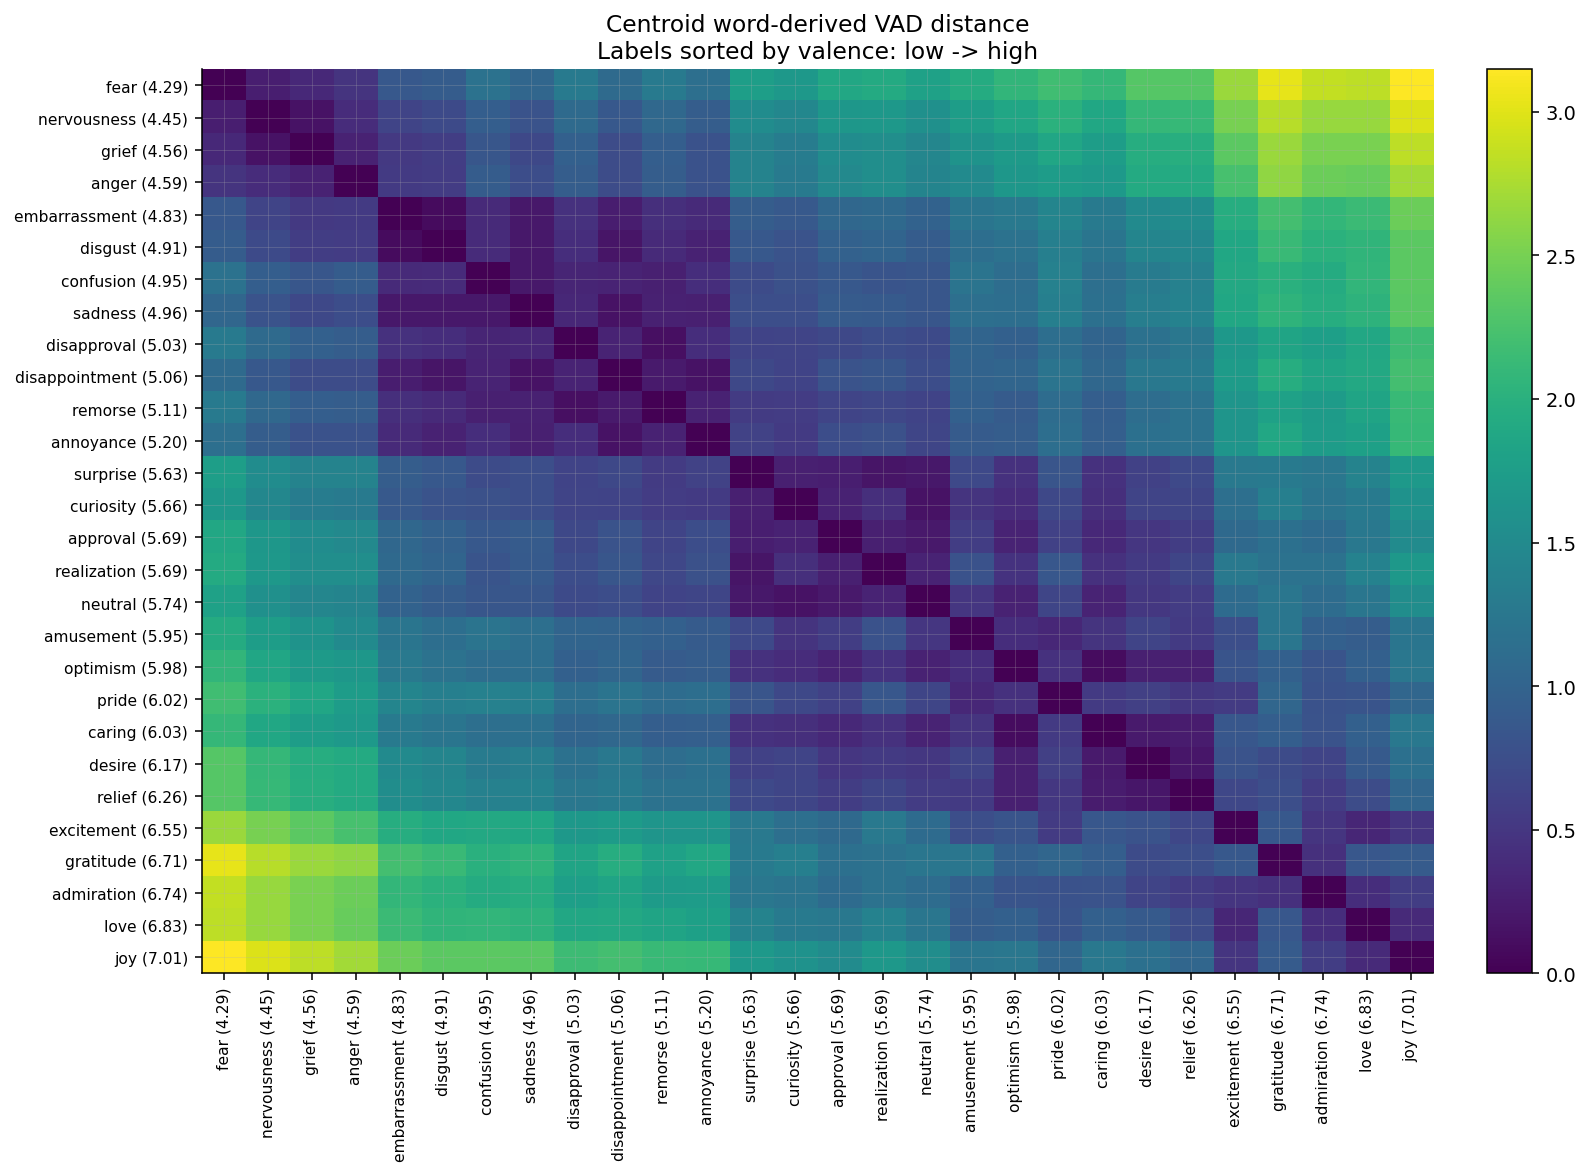

Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\word_vad_heatmap.png


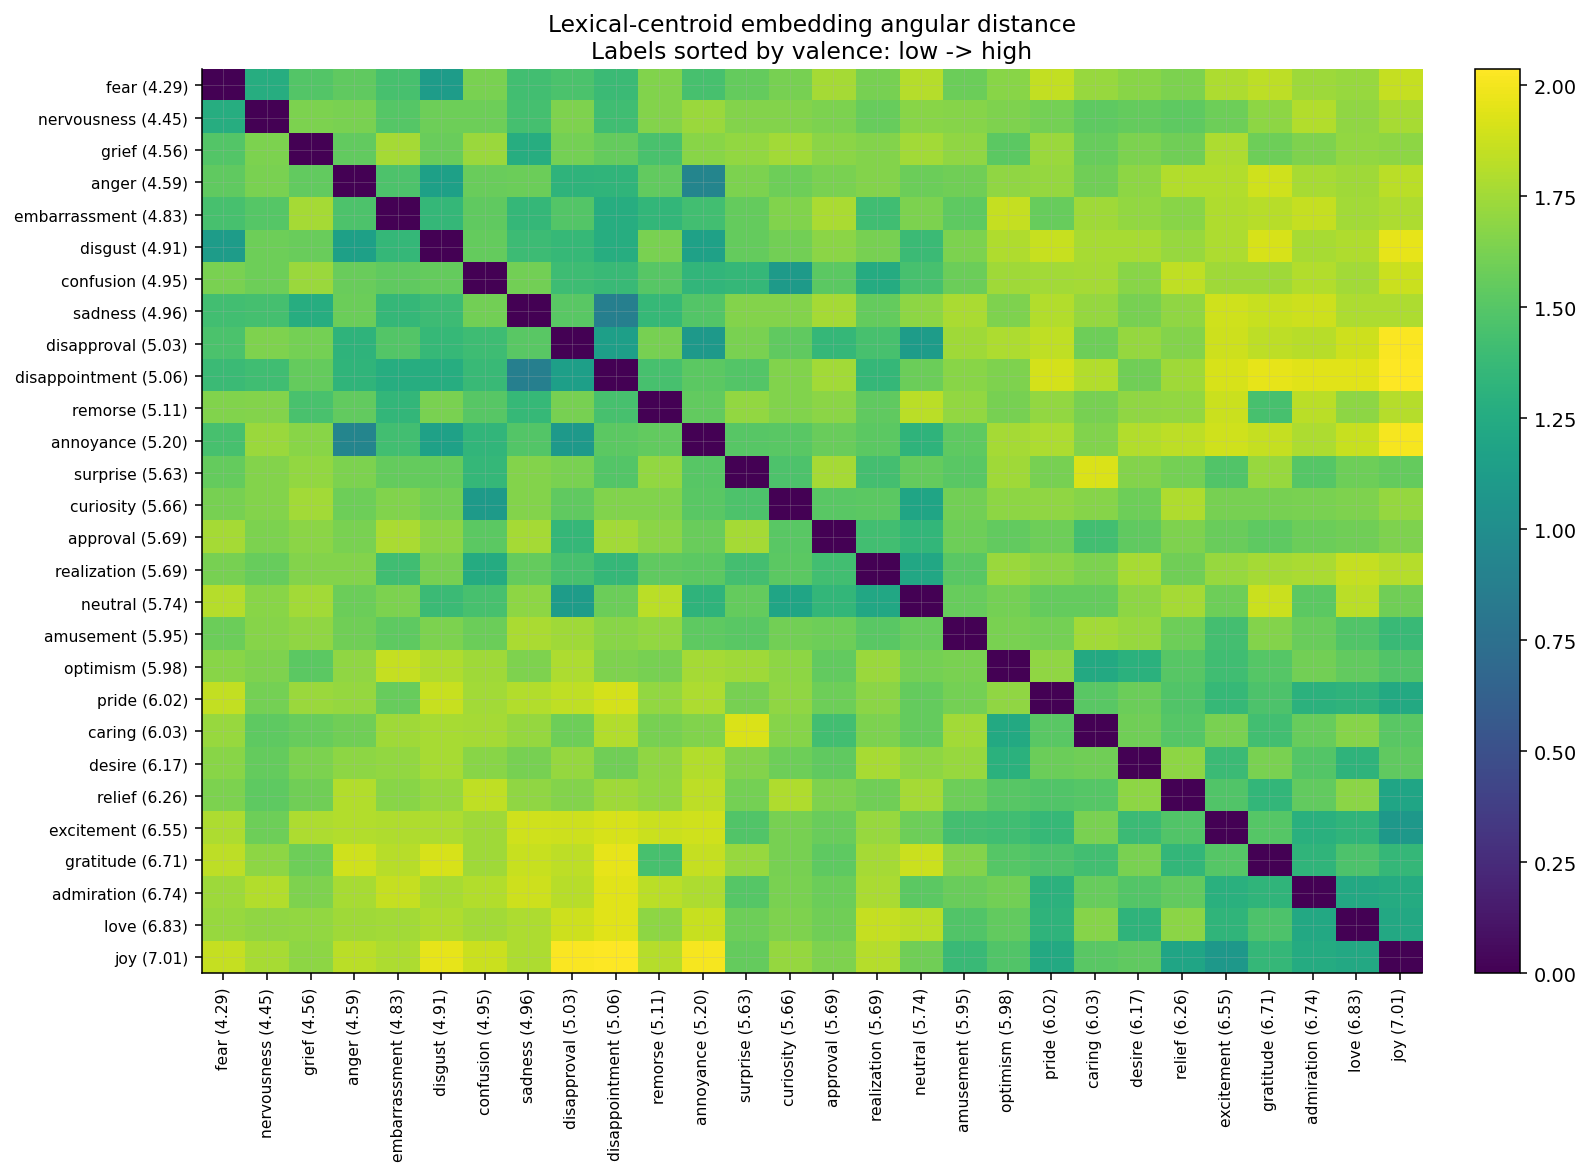

Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\embedding_angular_heatmap_ranked_by_word_valence.png


In [48]:
def plot_distance_heatmap_ranked_by_valence(D, centroid_df, title, out_path, valence_col="word_vad_valence"):
    order = np.argsort(centroid_df[valence_col].to_numpy())
    D_sorted = D[np.ix_(order, order)]
    label_names_sorted = centroid_df["label_name"].astype(str).to_numpy()[order]
    valence_sorted = centroid_df[valence_col].to_numpy()[order]

    fig, ax = plt.subplots(figsize=(11.5, 8.5))
    im = ax.imshow(D_sorted, aspect="auto")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_labels = [f"{lab} ({val:.2f})" for lab, val in zip(label_names_sorted, valence_sorted)]
    ax.set_xticks(np.arange(len(label_names_sorted)))
    ax.set_yticks(np.arange(len(label_names_sorted)))
    ax.set_xticklabels(tick_labels, rotation=90, fontsize=8)
    ax.set_yticklabels(tick_labels, fontsize=8)
    ax.set_title(title + "\nLabels sorted by valence: low -> high")
    fig.tight_layout()
    fig.savefig(out_path, dpi=220)
    plt.show()
    print("Saved:", out_path)


word_heatmap_path = OUT_DIR / "word_vad_heatmap.png"
plot_distance_heatmap_ranked_by_valence(
    D_lex_VAD,
    lexical_centroid_df,
    "Centroid word-derived VAD distance",
    word_heatmap_path,
)

# Optional companion heatmap for embedding distances on the same lexical centroids.
Z_lex_for_heatmap, _, _ = maybe_pca(X_lex_centroid, PAPER_LEXICAL_DIRECT_PCA_DIM, seed=SEED)
D_lex_embed_angle = angular_pairwise(Z_lex_for_heatmap)
plot_distance_heatmap_ranked_by_valence(
    D_lex_embed_angle,
    lexical_centroid_df,
    "Lexical-centroid embedding angular distance",
    OUT_DIR / "embedding_angular_heatmap_ranked_by_word_valence.png",
)


## 12. Centroid PCA plots and distance scatter

These are the useful centroid plots from the original centroid notebook.


Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\centroid_pca2_colored_by_valence.png
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\centroid_pca2_colored_by_valence.svg


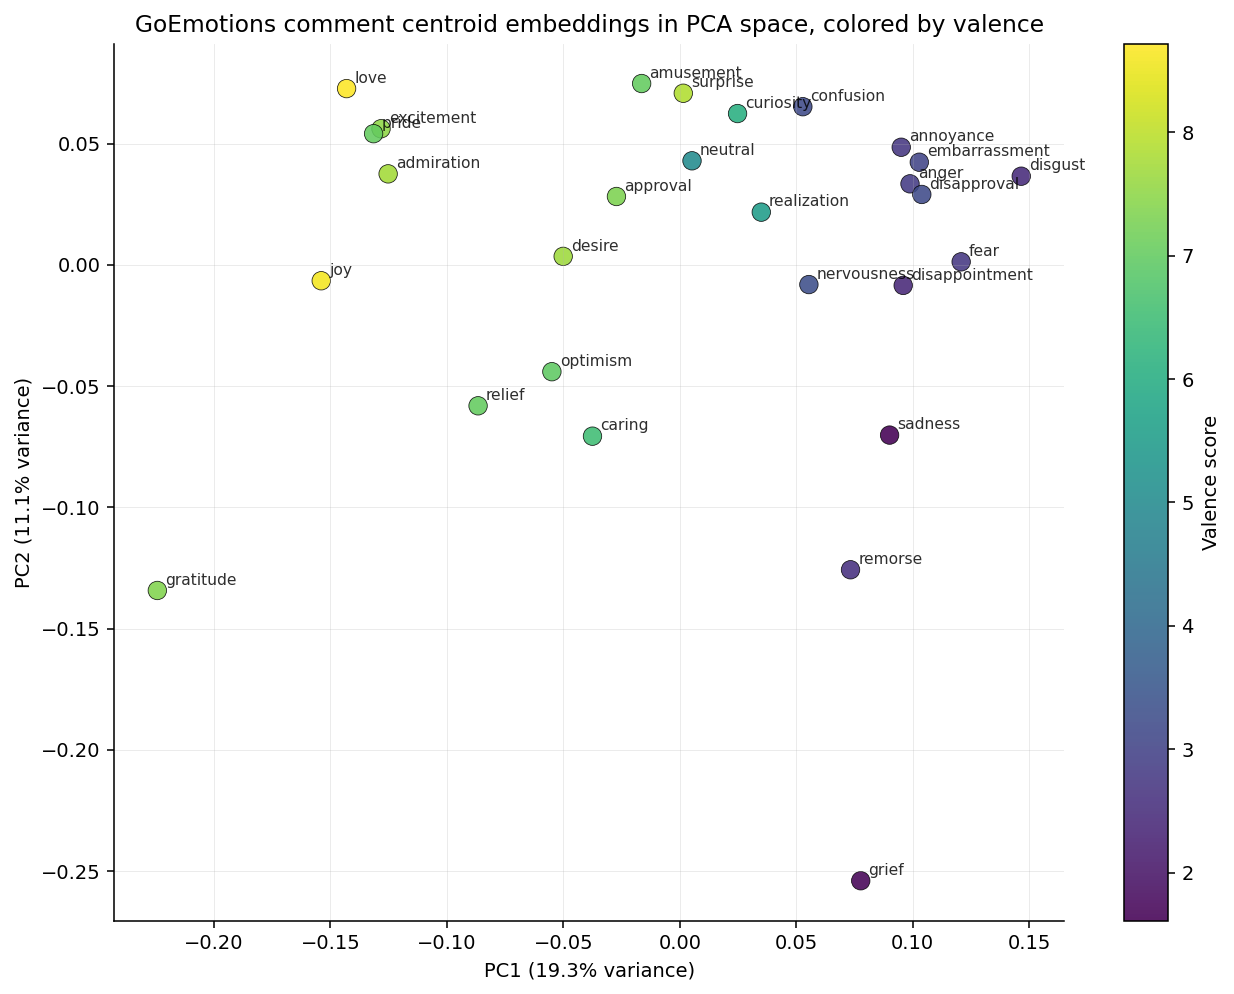

Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\centroid_pca2_colored_by_arousal.png
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\centroid_pca2_colored_by_arousal.svg


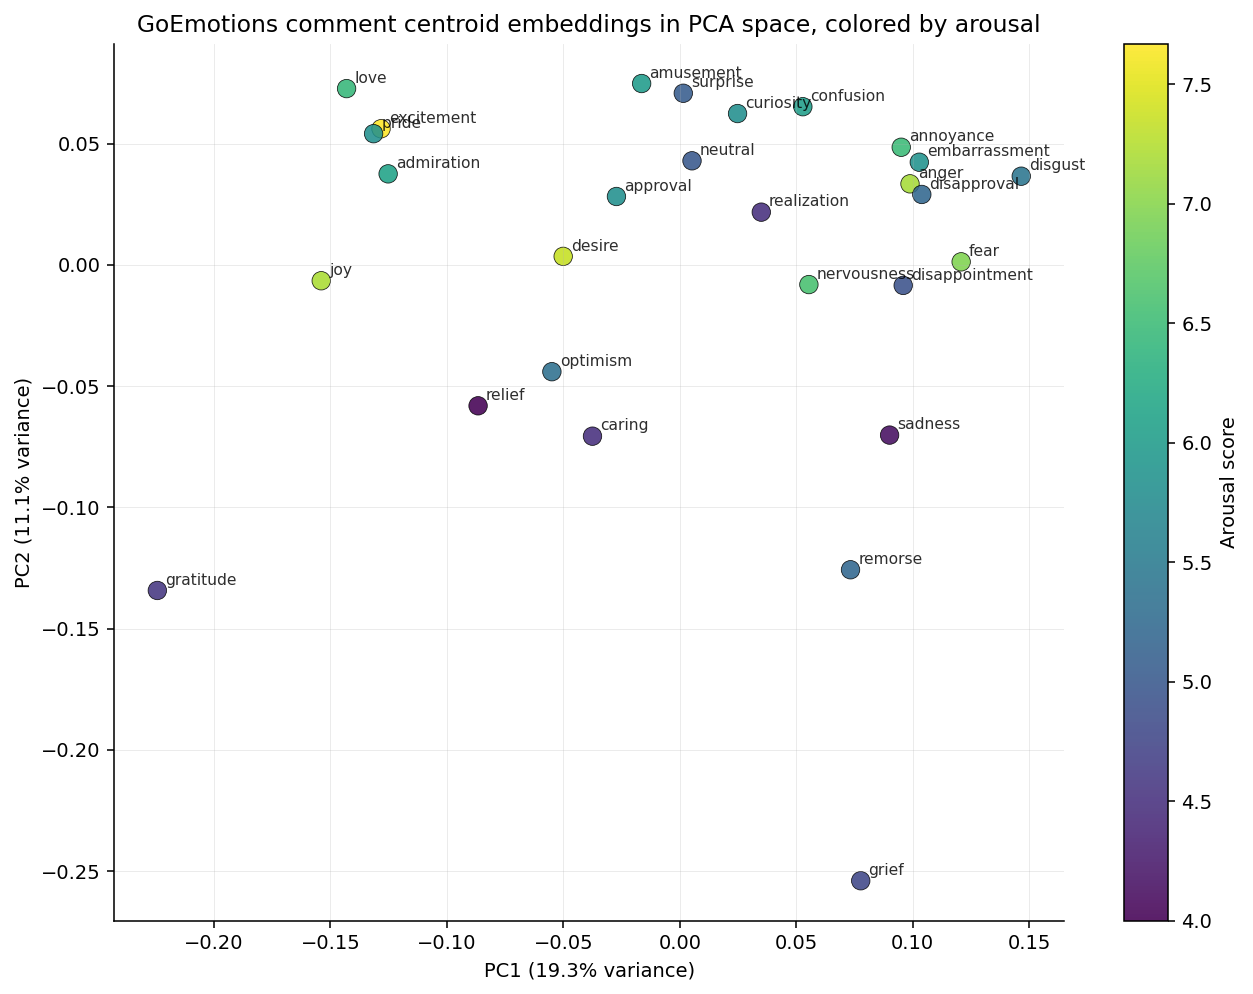

Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\centroid_pca2_colored_by_dominance.png
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\centroid_pca2_colored_by_dominance.svg


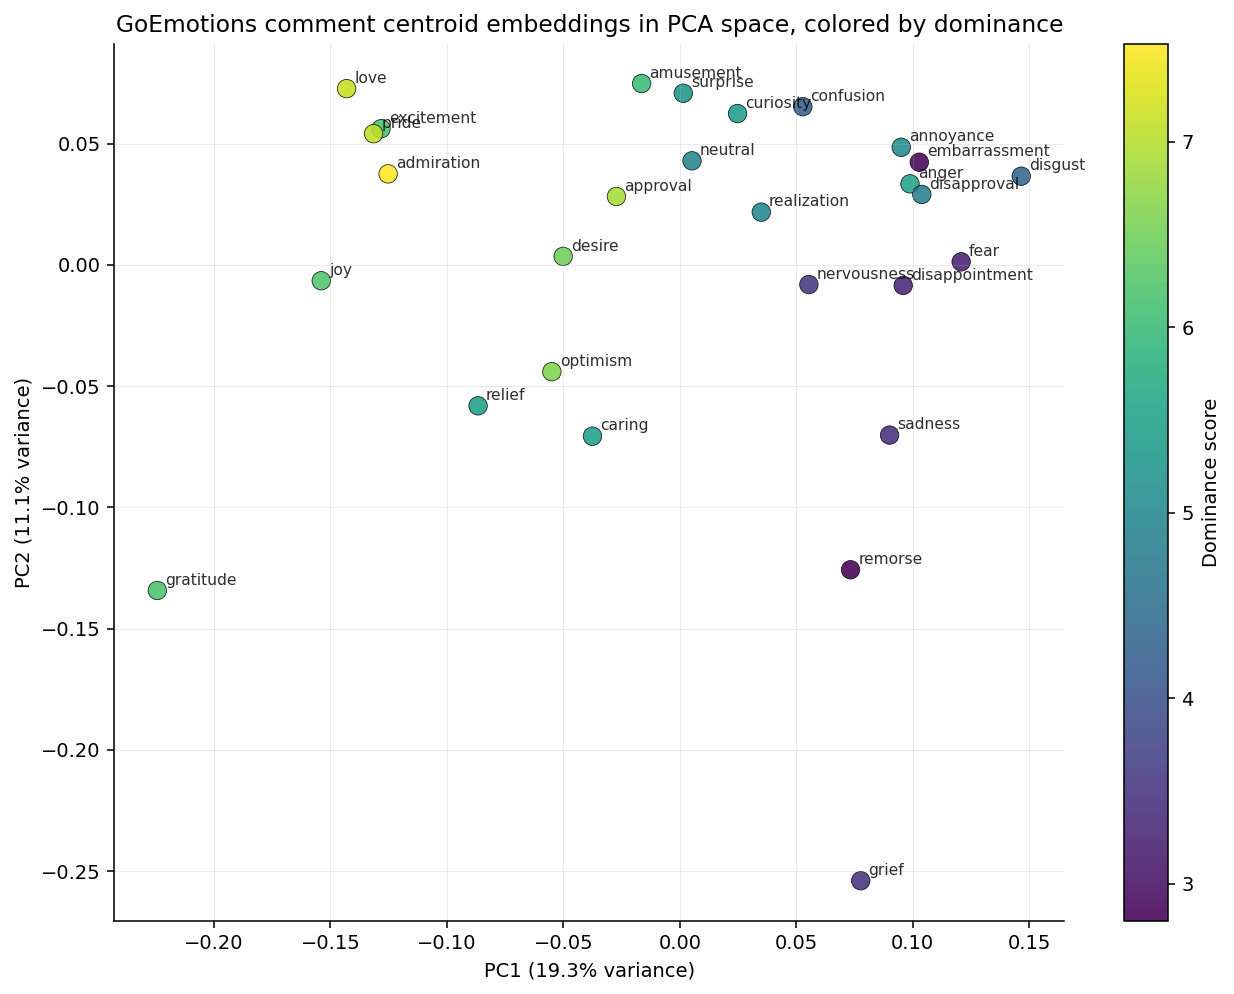

In [49]:
pca2 = PCA(n_components=2, random_state=SEED)
Z2_label = pca2.fit_transform(label_centroid_X)
explained = pca2.explained_variance_ratio_

for axis_name in ["valence", "arousal", "dominance"]:
    fig, ax = plt.subplots(figsize=(9.5, 7.2))
    sc = ax.scatter(
        Z2_label[:, 0],
        Z2_label[:, 1],
        c=label_centroid_meta[axis_name],
        s=90,
        alpha=0.88,
        edgecolor="black",
        linewidth=0.4,
    )
    for i, row in label_centroid_meta.reset_index(drop=True).iterrows():
        ax.annotate(
            row["label_name"],
            (Z2_label[i, 0], Z2_label[i, 1]),
            xytext=(4, 3),
            textcoords="offset points",
            fontsize=8,
            alpha=0.82,
        )
    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label(f"{axis_name.capitalize()} score")
    ax.set_xlabel(f"PC1 ({explained[0] * 100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({explained[1] * 100:.1f}% variance)")
    ax.set_title(f"GoEmotions comment centroid embeddings in PCA space, colored by {axis_name}")
    clean_axes(ax)
    fig.tight_layout()
    save_matplotlib(fig, f"centroid_pca2_colored_by_{axis_name}")
    plt.show()


Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\label_centroid_direct_angle_vs_label_V_scatter.png
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\label_centroid_direct_angle_vs_label_V_scatter.svg


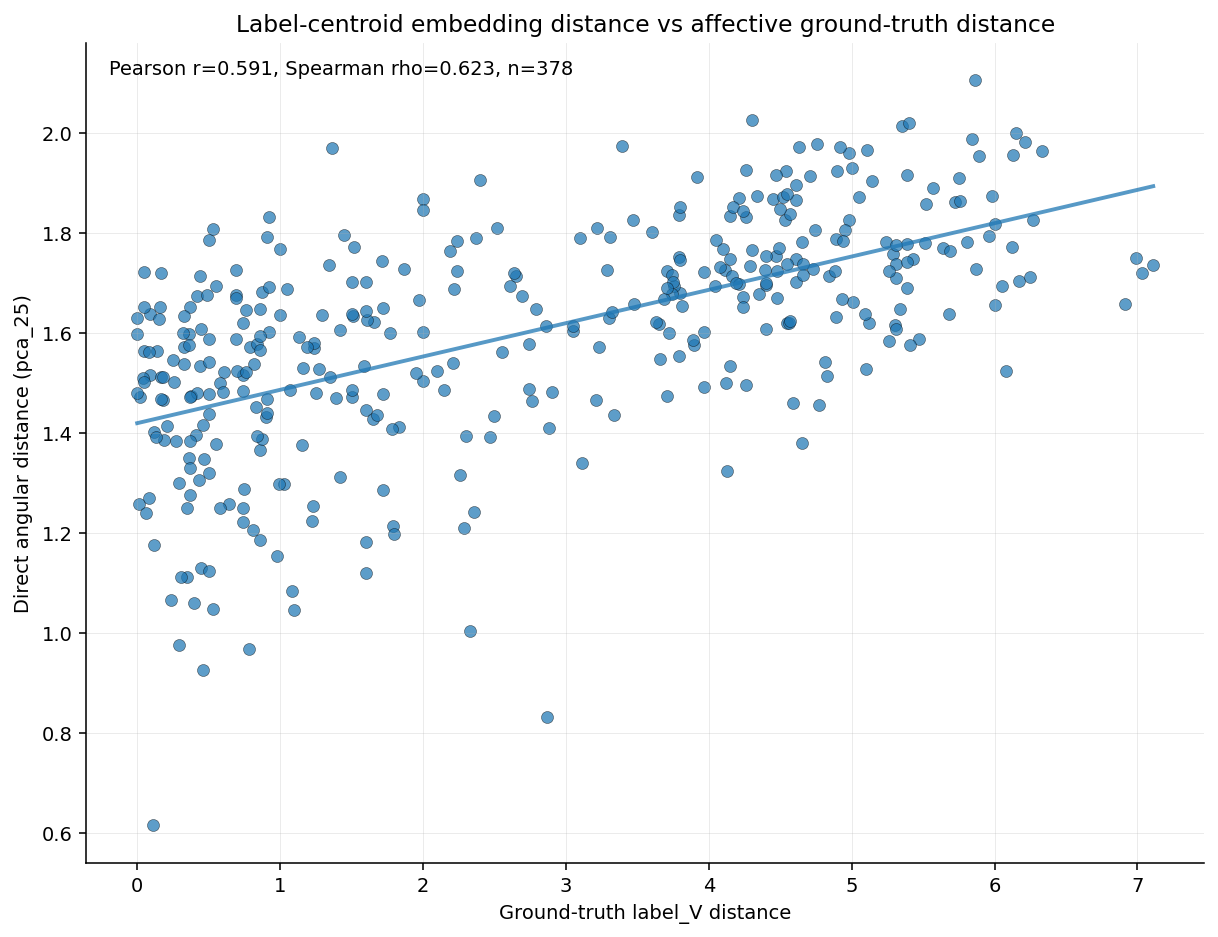

Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\label_centroid_direct_angle_vs_label_VAD_scatter.png
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\label_centroid_direct_angle_vs_label_VAD_scatter.svg


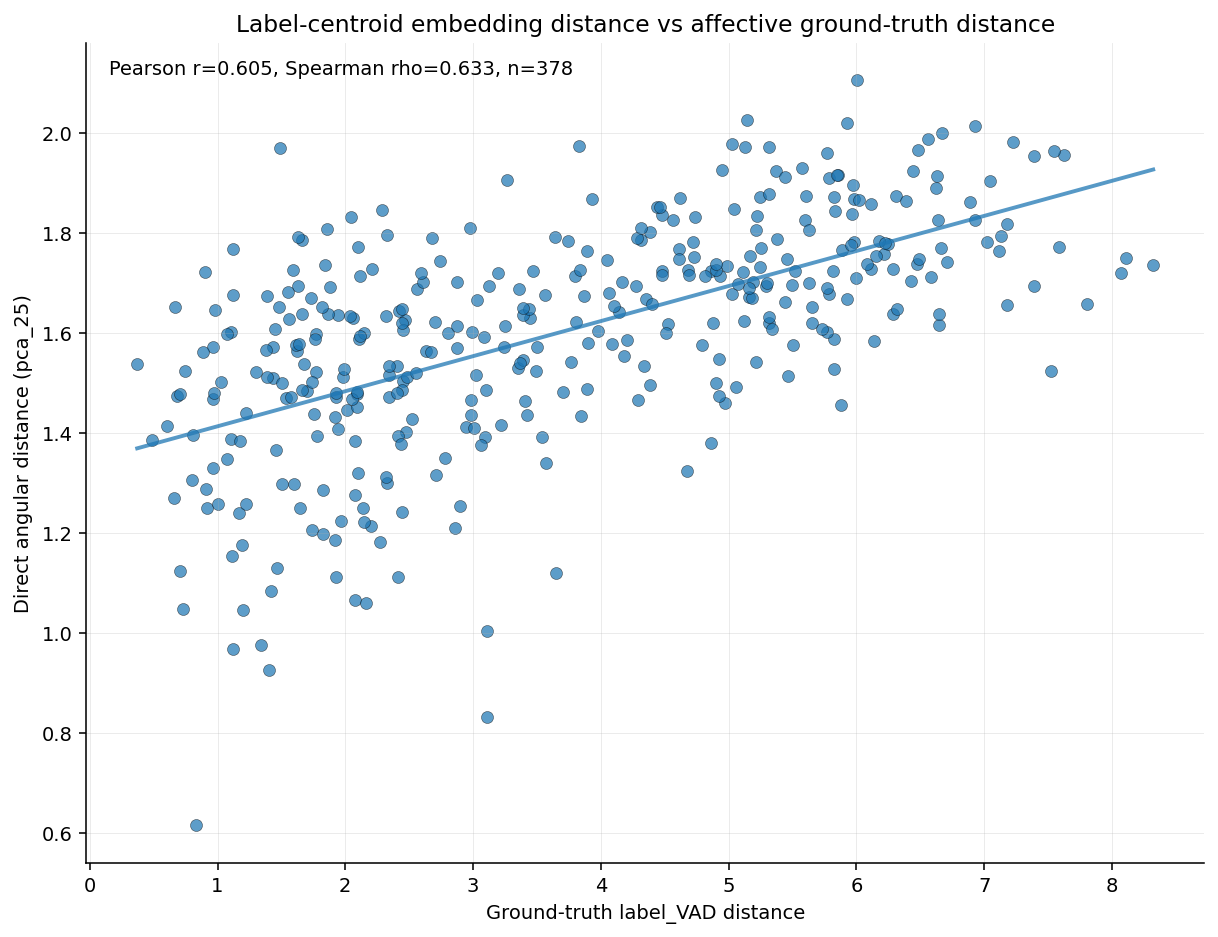

In [50]:
def upper_triangle_frame(D_x: np.ndarray, D_y: np.ndarray, labels: list[str], x_name: str, y_name: str) -> pd.DataFrame:
    iu = np.triu_indices(D_x.shape[0], k=1)
    return pd.DataFrame({
        "label_i": [labels[i] for i in iu[0]],
        "label_j": [labels[j] for j in iu[1]],
        x_name: D_x[iu],
        y_name: D_y[iu],
    })


# Scatter for the direct label-centroid setting used in the compact table.
Z_label_direct, label_direct_rep, _ = maybe_pca(label_centroid_X, PAPER_LABEL_DIRECT_PCA_DIM, seed=SEED)
D_label_angle = angular_pairwise(Z_label_direct)
labels = label_centroid_meta["label_name"].tolist()

for truth_name, D_truth in {"label_V": D_label_V, "label_VAD": D_label_VAD}.items():
    pair_df = upper_triangle_frame(
        D_label_angle,
        D_truth,
        labels=labels,
        x_name="embedding_distance",
        y_name="ground_truth_distance",
    )
    finite = np.isfinite(pair_df["embedding_distance"]) & np.isfinite(pair_df["ground_truth_distance"])
    plot_df = pair_df.loc[finite].copy()
    stats = corr_stats(plot_df["ground_truth_distance"].to_numpy(), plot_df["embedding_distance"].to_numpy())

    fig, ax = plt.subplots(figsize=(8.8, 6.8))
    ax.scatter(
        plot_df["ground_truth_distance"],
        plot_df["embedding_distance"],
        s=38,
        alpha=0.72,
        edgecolor="black",
        linewidth=0.25,
    )
    if len(plot_df) >= 3 and plot_df["ground_truth_distance"].std() > 0:
        x = plot_df["ground_truth_distance"].to_numpy()
        y = plot_df["embedding_distance"].to_numpy()
        slope, intercept = np.polyfit(x, y, deg=1)
        xs = np.linspace(x.min(), x.max(), 200)
        ax.plot(xs, slope * xs + intercept, linewidth=2, alpha=0.75)

    ax.set_xlabel(f"Ground-truth {truth_name} distance")
    ax.set_ylabel(f"Direct angular distance ({label_direct_rep})")
    ax.set_title("Label-centroid embedding distance vs affective ground-truth distance")
    ax.text(
        0.02,
        0.98,
        f"Pearson r={stats['pearson_r']:.3f}, Spearman rho={stats['spearman_rho']:.3f}, n={stats['n_pairs']}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=10,
    )
    clean_axes(ax)
    fig.tight_layout()
    save_matplotlib(fig, f"label_centroid_direct_angle_vs_{truth_name}_scatter")
    plt.show()


## 13. Optional 3D PCA plot for selected labels

This cell saves an interactive HTML plot. Static PNG export requires `kaleido`, because apparently one dependency was not enough.


In [55]:
if HAS_PLOTLY:
    focus_meta = metadata[metadata["label_name"].isin(FOCUS_LABELS)].copy().reset_index(drop=False)
    focus_meta = focus_meta.rename(columns={"index": "_row_original"})

    if MAX_3D_PER_LABEL is not None:
        focus_meta = (
            focus_meta.groupby("label_name", group_keys=False)
            .apply(lambda g: g.sample(n=min(len(g), int(MAX_3D_PER_LABEL)), random_state=SEED))
            .reset_index(drop=True)
        )

    if focus_meta.empty:
        raise ValueError(f"No comments found for labels: {FOCUS_LABELS}")

    X_focus = X[focus_meta["_embedding_row"].to_numpy()]

    if PCA_3D_FIT_SCOPE == "global":
        pca3 = PCA(n_components=3, random_state=SEED)
        pca3.fit(X)
        Z3 = pca3.transform(X_focus)
    elif PCA_3D_FIT_SCOPE == "selected":
        pca3 = PCA(n_components=3, random_state=SEED)
        Z3 = pca3.fit_transform(X_focus)
    else:
        raise ValueError("PCA_3D_FIT_SCOPE must be 'global' or 'selected'")

    plot3d = focus_meta[["label_name", "text"]].copy()
    plot3d["PC1"] = Z3[:, 0]
    plot3d["PC2"] = Z3[:, 1]
    plot3d["PC3"] = Z3[:, 2]

    label_order = [label for label in FOCUS_LABELS if label in set(plot3d["label_name"])]
    colors = px.colors.qualitative.Safe + px.colors.qualitative.Dark24
    color_map = {label: colors[i % len(colors)] for i, label in enumerate(label_order)}

    fig = go.Figure()
    for label in label_order:
        df_lab = plot3d[plot3d["label_name"] == label]
        fig.add_trace(go.Scatter3d(
            x=df_lab["PC1"], y=df_lab["PC2"], z=df_lab["PC3"],
            mode="markers",
            name=f"{label} comments (n={len(df_lab)})",
            marker=dict(size=3.2, opacity=0.72, color=color_map[label]),
            text=df_lab["text"],
            hovertemplate=(
                f"label={label}<br>"
                "PC1=%{x:.3f}<br>PC2=%{y:.3f}<br>PC3=%{z:.3f}<br>"
                "%{text}<extra></extra>"
            ),
        ))
        pts = df_lab[["PC1", "PC2", "PC3"]].to_numpy()
        mean = pts.mean(axis=0)
        fig.add_trace(go.Scatter3d(
            x=[mean[0]], y=[mean[1]], z=[mean[2]],
            mode="markers+text",
            name=f"{label} mean",
            marker=dict(size=8, symbol="diamond", color=color_map[label]),
            text=[label],
            textposition="top center",
        ))

    fig.update_layout(
        title=f"Selected labels in 3D PCA space ({PCA_3D_FIT_SCOPE} fit)",
        #scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3"),
        legend=dict(itemsizing="constant"),
        width=1000,
        height=800,
    )

    html_path = OUT_DIR / "selected_labels_pca3.html"
    fig.write_html(html_path)
    print("Saved:", html_path)
    fig.show()
else:
    print("Plotly is not installed; skipping 3D PCA HTML plot.")


Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\selected_labels_pca3.html


## 14. Individual-comment diagnostics

This section keeps the useful word-level checks without reviving the old coverage plot. Coverage is still saved as CSV because boring diagnostics are often the ones preventing embarrassment.


Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\word_vad_coverage_by_label.csv


,label_name,total,usable,mean_coverage,median_vad_words,usable_rate
7,curiosity,201,186,0.290721,4.0,0.925373
10,disapproval,201,186,0.290408,4.0,0.925373
13,excitement,201,186,0.365343,3.0,0.925373
27,surprise,201,188,0.294655,3.0,0.935323
1,amusement,201,189,0.283721,3.0,0.940299
4,approval,201,192,0.307865,4.0,0.955224
20,neutral,201,192,0.322357,4.0,0.955224
24,relief,71,68,0.305195,3.0,0.957746
26,sadness,201,193,0.306565,4.0,0.960199
9,disappointment,201,194,0.296283,4.0,0.965174


Best comment-level candidate:


,ground_truth_distance,level,embedding_distance,representation,pca_dim,knn_k,graph_components,explained_variance,n_pairs,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p,abs_spearman
1,Comment VAD,individual comments,d_angle,pca_25,25,,,0.259941,940506,0.095614,0.0,0.094791,0.0,0.063273,0.0,0.094791


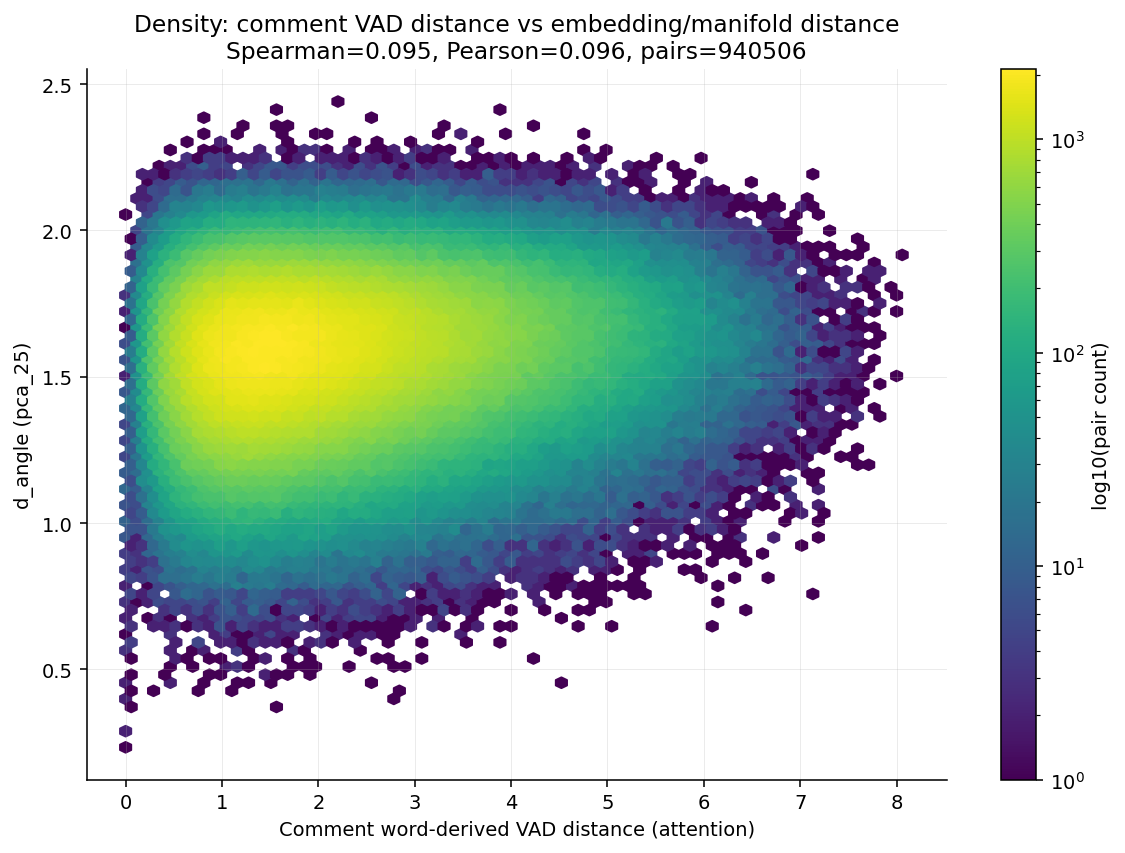

Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\comment_vad_vs_best_embedding_distance_density.png


In [52]:
# Save coverage table, but no coverage plot.
coverage_by_label = (
    comment_vad.groupby("label_name")
    .agg(
        total=("label_name", "size"),
        usable=("has_word_vad", "sum"),
        mean_coverage=("coverage", "mean"),
        median_vad_words=("n_vad_words", "median"),
    )
    .reset_index()
)
coverage_by_label["usable_rate"] = coverage_by_label["usable"] / coverage_by_label["total"]
coverage_path = OUT_DIR / "word_vad_coverage_by_label.csv"
coverage_by_label.to_csv(coverage_path, index=False)
print("Saved:", coverage_path)
display(coverage_by_label.sort_values("usable_rate"))

# Scatter/hexbin for comment VAD vs whichever embedding distance is strongest among the comment candidates.
comment_candidates = all_candidates[all_candidates["ground_truth_distance"].eq("Comment VAD")].copy()
if not comment_candidates.empty:
    comment_candidates["abs_spearman"] = comment_candidates["spearman_rho"].abs()
    best_comment = comment_candidates.sort_values("abs_spearman", ascending=False).iloc[0]
    print("Best comment-level candidate:")
    display(best_comment.to_frame().T)

    # Reconstruct the chosen representation distance.
    if best_comment["embedding_distance"] == "d_angle":
        Z_best, _, _ = maybe_pca(X_sample, int(best_comment["pca_dim"]), seed=SEED)
        D_rep_best = angular_pairwise(Z_best)
    else:
        Z_best, _, _ = maybe_pca(X_sample, int(best_comment["pca_dim"]), seed=SEED)
        D_rep_best, _, _ = knn_geodesic_distance(
            Z_best,
            k=_as_int_or_empty(best_comment["knn_k"]),
            metric="angular",
            k_max=COMMENT_KNN_K_MAX,
        )

    truth_upper = upper_values(D_comment_VAD)
    rep_upper = upper_values(D_rep_best)
    mask = np.isfinite(truth_upper) & np.isfinite(rep_upper)
    truth_clean = truth_upper[mask]
    rep_clean = rep_upper[mask]

    fig, ax = plt.subplots(figsize=(8.5, 6.2))
    hb = ax.hexbin(truth_clean, rep_clean, gridsize=70, bins="log", mincnt=1)
    fig.colorbar(hb, ax=ax, label="log10(pair count)")
    ax.set_xlabel(f"Comment word-derived VAD distance ({PAPER_COMMENT_VAD_MODE})")
    ax.set_ylabel(f"{best_comment['embedding_distance']} ({best_comment['representation']})")
    ax.set_title(
        "Density: comment VAD distance vs embedding/manifold distance\n"
        f"Spearman={best_comment['spearman_rho']:.3f}, Pearson={best_comment['pearson_r']:.3f}, pairs={int(best_comment['n_pairs'])}"
    )
    clean_axes(ax)
    fig.tight_layout()
    density_path = OUT_DIR / "comment_vad_vs_best_embedding_distance_density.png"
    fig.savefig(density_path, dpi=220)
    plt.show()
    print("Saved:", density_path)


Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\label_vad_centroid_vs_d_angle_pca25_scatter.png
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\label_vad_centroid_vs_d_angle_pca25_scatter.svg


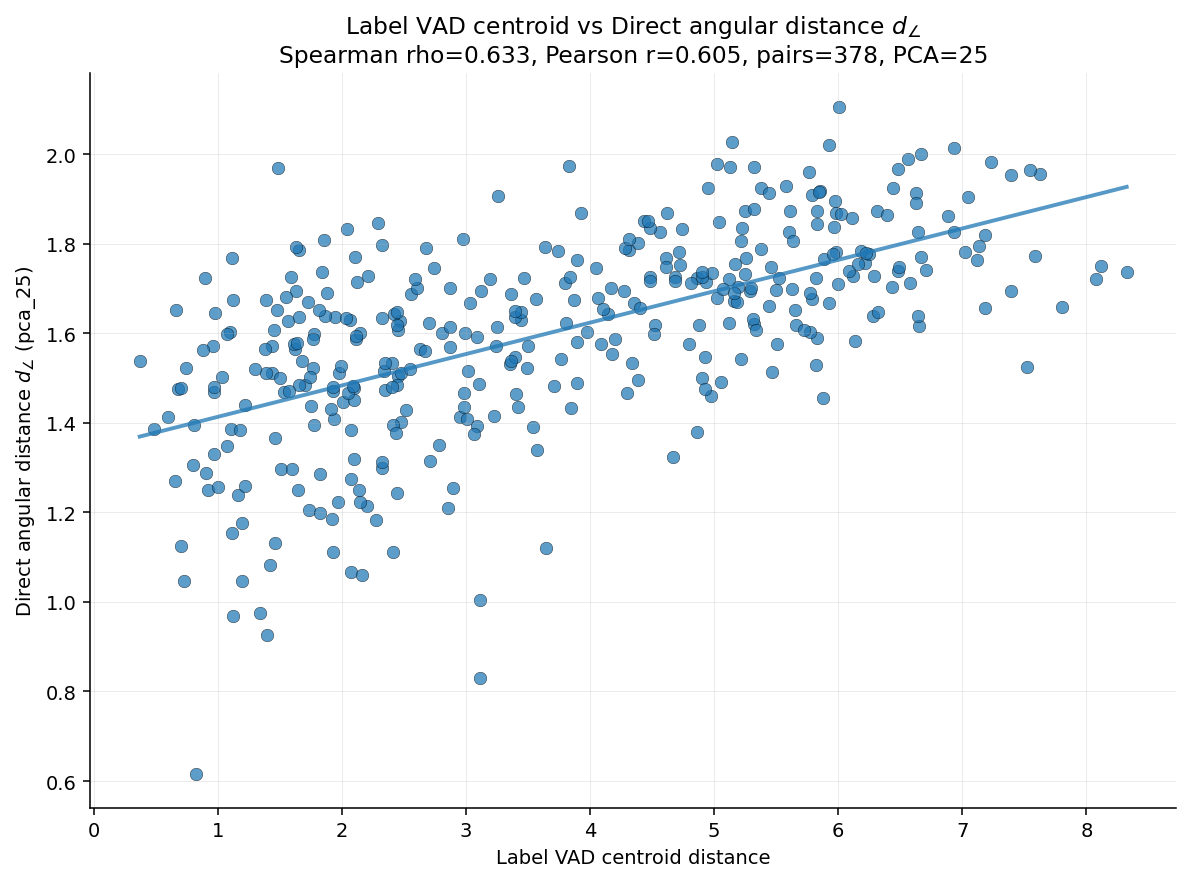

Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\label_vad_centroid_vs_d_G_pca25_scatter.png
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\label_vad_centroid_vs_d_G_pca25_scatter.svg


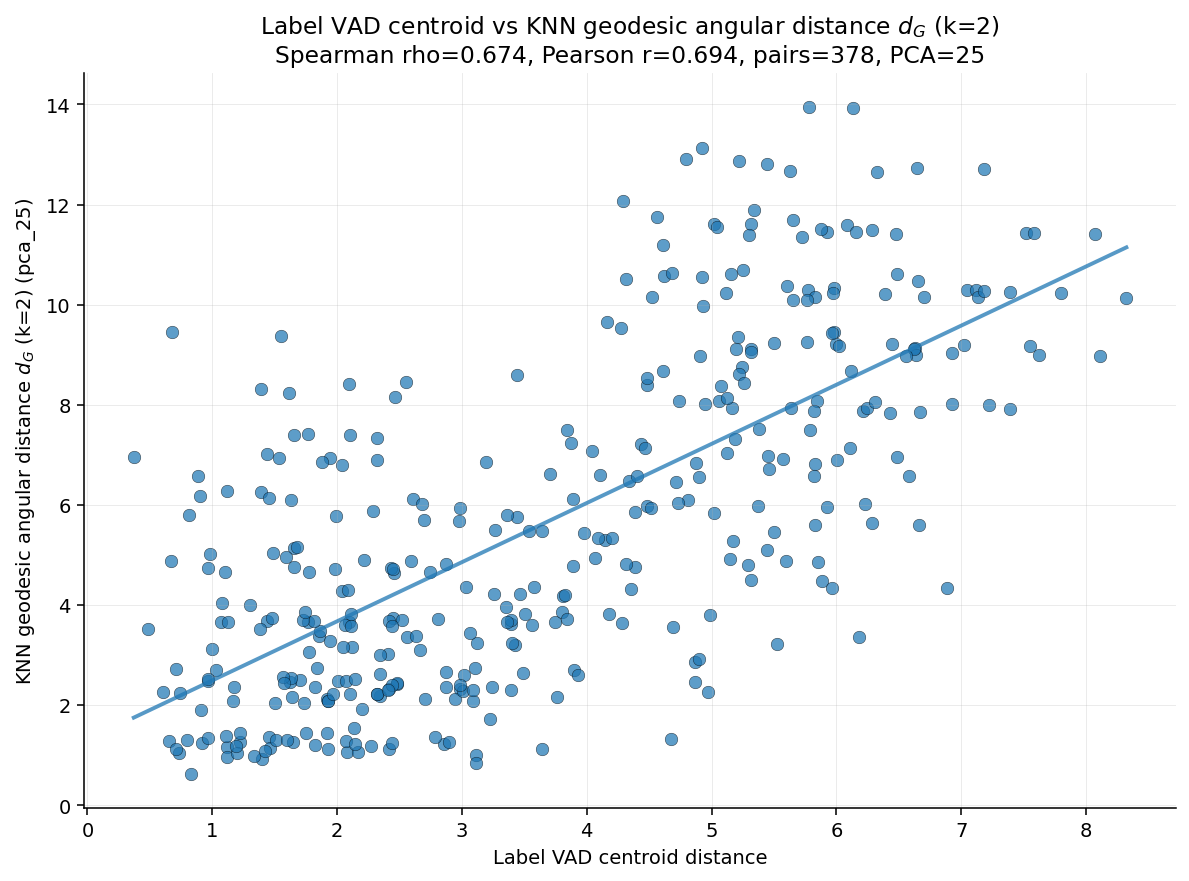

Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\comment_vad_centroid_vs_d_angle_pca25_scatter.png
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\comment_vad_centroid_vs_d_angle_pca25_scatter.svg


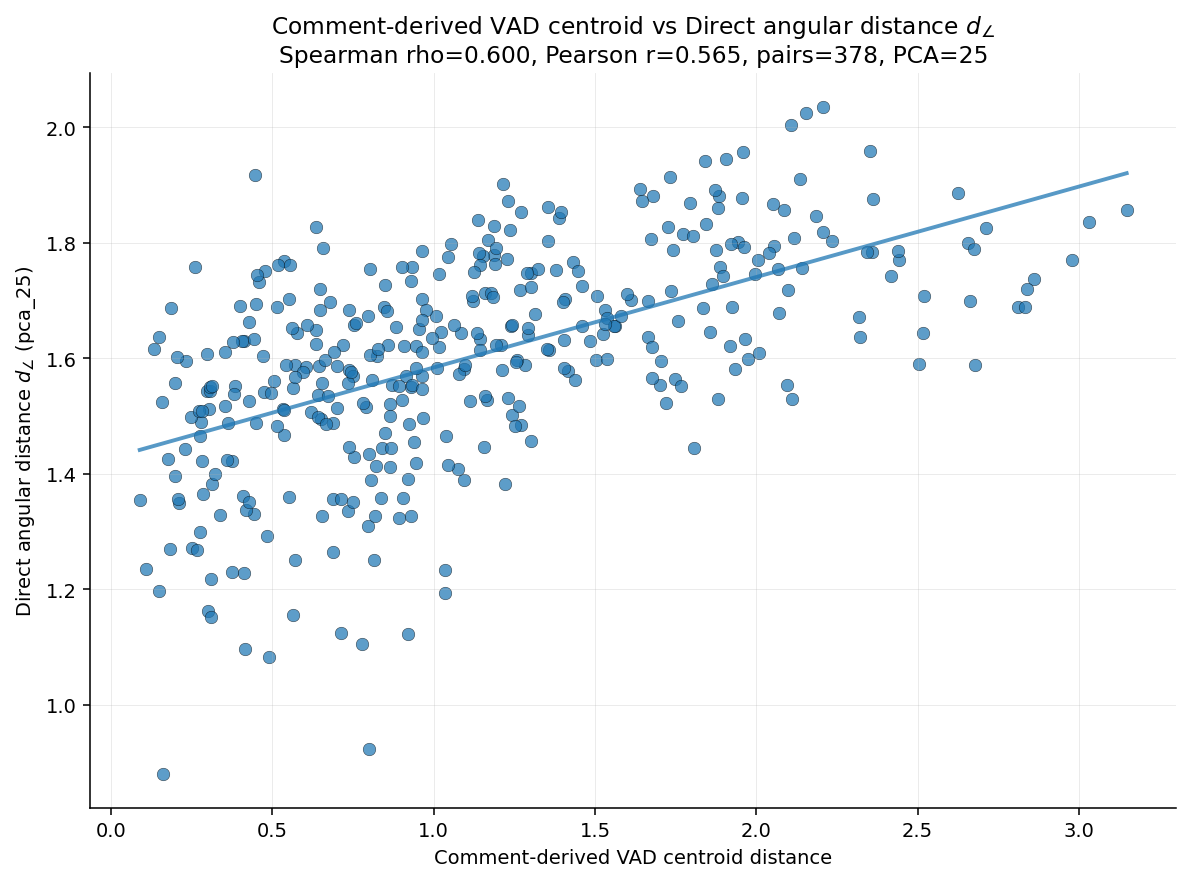

Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\comment_vad_centroid_vs_d_G_pca25_scatter.png
Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\comment_vad_centroid_vs_d_G_pca25_scatter.svg


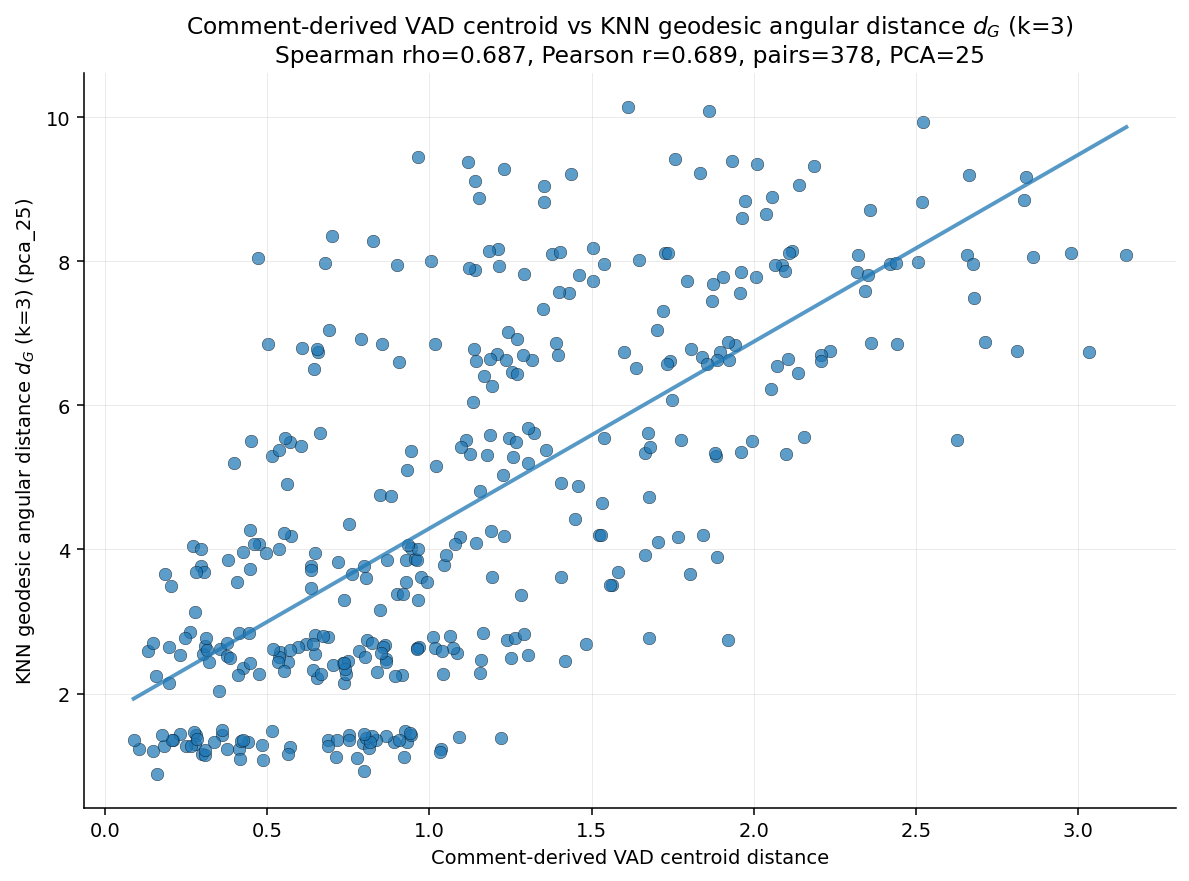

Saved: D:\pyprojects\m4r\new_plots\merged_ground_truth_table_pca25_connectedk\centroid_vad_four_scatter_stats.csv


,ground_truth_distance,embedding_distance,pca_dim,representation,explained_variance,knn_k,graph_components,n_pairs,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p
0,Label VAD centroid,d_angle,25,pca_25,0.992096,,,378,0.604641,4.743202e-39,0.633224,9.348724e-44,0.442871,7.990012e-38
1,Label VAD centroid,d_G,25,pca_25,0.992096,2,1,378,0.694175,1.214858e-55,0.674093,2.071191e-51,0.475011,2.982520e-43
2,Comment-derived VAD centroid,d_angle,25,pca_25,0.982408,,,378,0.565071,2.848138e-33,0.600349,2.197918e-38,0.417344,8.793171e-34
3,Comment-derived VAD centroid,d_G,25,pca_25,0.982408,3,1,378,0.688661,1.908798e-54,0.686748,4.892212e-54,0.486169,3.160791e-45


In [53]:
# Four centroid-level VAD scatter plots for Table 3.1.
# Fixed setting: PCA-25 for both d_angle and d_G; d_G uses the least k that connects the graph.

CENTROID_VAD_SCATTER_PCA_DIM = TABLE_PCA_DIM
CENTROID_VAD_SCATTER_K = "auto"


def centroid_vad_scatter_stats_and_plot(
    X_centroid: np.ndarray,
    D_truth: np.ndarray,
    labels: list[str],
    truth_display_name: str,
    truth_slug: str,
    embedding_kind: str,
    out_slug: str,
):
    """Plot one centroid-level ground-truth distance matrix against one embedding distance matrix."""
    Z, rep_name, ev = maybe_pca(X_centroid, CENTROID_VAD_SCATTER_PCA_DIM, seed=SEED)

    if embedding_kind == "d_angle":
        D_embedding = angular_pairwise(Z)
        method_label = r"Direct angular distance $d_{\angle}$"
        k_used = ""
        components = ""
    elif embedding_kind == "d_G":
        D_embedding, k_used, components = knn_geodesic_distance(
            Z,
            k=CENTROID_VAD_SCATTER_K,
            metric="angular",
            k_max=CENTROID_KNN_K_MAX,
        )
        method_label = rf"KNN geodesic angular distance $d_G$ (k={k_used})"
    else:
        raise ValueError("embedding_kind must be 'd_angle' or 'd_G'")

    truth_upper = upper_values(D_truth)
    embedding_upper = upper_values(D_embedding)
    mask = np.isfinite(truth_upper) & np.isfinite(embedding_upper)
    truth_clean = truth_upper[mask]
    embedding_clean = embedding_upper[mask]
    stats = corr_stats(truth_clean, embedding_clean)

    fig, ax = plt.subplots(figsize=(8.6, 6.4))
    ax.scatter(
        truth_clean,
        embedding_clean,
        s=42,
        alpha=0.72,
        edgecolor="black",
        linewidth=0.25,
    )

    if len(truth_clean) >= 3 and np.std(truth_clean) > 0 and np.std(embedding_clean) > 0:
        slope, intercept = np.polyfit(truth_clean, embedding_clean, deg=1)
        xs = np.linspace(truth_clean.min(), truth_clean.max(), 200)
        ax.plot(xs, slope * xs + intercept, linewidth=2, alpha=0.75)

    ax.set_xlabel(f"{truth_display_name} distance")
    ax.set_ylabel(f"{method_label} ({rep_name})")
    ax.set_title(
        f"{truth_display_name} vs {method_label}\n"
        f"Spearman rho={stats['spearman_rho']:.3f}, Pearson r={stats['pearson_r']:.3f}, "
        f"pairs={stats['n_pairs']}, PCA={CENTROID_VAD_SCATTER_PCA_DIM}"
    )
    clean_axes(ax)
    fig.tight_layout()
    save_matplotlib(fig, out_slug)
    plt.show()

    return {
        "ground_truth_distance": truth_display_name,
        "embedding_distance": embedding_kind,
        "pca_dim": CENTROID_VAD_SCATTER_PCA_DIM,
        "representation": rep_name,
        "explained_variance": ev,
        "knn_k": k_used,
        "graph_components": components,
        **stats,
    }


centroid_vad_plot_specs = [
    {
        "X_centroid": label_centroid_X,
        "D_truth": D_label_VAD,
        "labels": label_centroid_meta["label_name"].astype(str).tolist(),
        "truth_display_name": "Label VAD centroid",
        "truth_slug": "label_vad_centroid",
    },
    {
        "X_centroid": X_lex_centroid,
        "D_truth": D_lex_VAD,
        "labels": lexical_centroid_df["label_name"].astype(str).tolist(),
        "truth_display_name": "Comment-derived VAD centroid",
        "truth_slug": "comment_vad_centroid",
    },
]

centroid_vad_plot_rows = []
for spec in centroid_vad_plot_specs:
    for embedding_kind in ["d_angle", "d_G"]:
        centroid_vad_plot_rows.append(
            centroid_vad_scatter_stats_and_plot(
                X_centroid=spec["X_centroid"],
                D_truth=spec["D_truth"],
                labels=spec["labels"],
                truth_display_name=spec["truth_display_name"],
                truth_slug=spec["truth_slug"],
                embedding_kind=embedding_kind,
                out_slug=f"{spec['truth_slug']}_vs_{embedding_kind}_pca{CENTROID_VAD_SCATTER_PCA_DIM}_scatter",
            )
        )

centroid_vad_plot_stats = pd.DataFrame(centroid_vad_plot_rows)
centroid_vad_plot_stats_path = OUT_DIR / "centroid_vad_four_scatter_stats.csv"
centroid_vad_plot_stats.to_csv(centroid_vad_plot_stats_path, index=False)
print("Saved:", centroid_vad_plot_stats_path)
display(centroid_vad_plot_stats)
